<a href="https://colab.research.google.com/github/Faxsito/E1-Calidad-Preparacion-Datos/blob/main/E1%20-%20EDA/E1_Calidad_Preparacion_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 1 – Calidad y Preparación de Datos

## Análisis del rendimiento académico

En este notebook se realizará el diagnóstico de calidad, análisis exploratorio y preparación del dataset `rendimiento_academico_evaluacion.csv`.

El objetivo es identificar posibles problemas presentes en los datos, analizar sus principales características y posteriormente aplicar estrategias de tratamiento justificadas a partir de la evidencia obtenida.

# 0. Preparación y revisión inicial
### 0.1 Preparación del entorno

En esta sección se importan las librerías necesarias para trabajar con el dataset, realizar cálculos, generar visualizaciones y posteriormente preparar los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

### 0.2 Carga y revisión inicial del dataset

En esta sección se carga el archivo `rendimiento_academico_evaluacion.csv` y se realiza una primera inspección de su estructura.

El objetivo es conocer el dataset tal como fue entregado, sin realizar todavía operaciones de limpieza o transformación.:

In [2]:
!wget -O rendimiento_academico_evaluacion.csv "https://raw.githubusercontent.com/Faxsito/E1-Calidad-Preparacion-Datos/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv"

df = pd.read_csv("rendimiento_academico_evaluacion.csv")

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

df.head()

--2026-09-03 00:32:41--  https://raw.githubusercontent.com/Faxsito/E1-Calidad-Preparacion-Datos/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.04s   

2026-09-03 00:32:41 (10.1 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]

Dataset cargado correctamente.
Dimensiones: (5100, 11)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


In [3]:
df.head()

,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


In [4]:
df.shape

(5100, 11)

In [5]:
df.columns

Index(['StudentID', 'Age', 'StudyHours', 'Attendance', 'PreviousGPA',
       'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'Scholarship',
       'Program', 'FinalGrade'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


In [7]:
df.dtypes

,0
StudentID,object
Age,float64
StudyHours,float64
Attendance,float64
PreviousGPA,float64
AssignmentsCompleted,float64
SleepHours,float64
InternetHours,float64
Scholarship,object
Program,object


## Interpretación de la revisión inicial

El dataset contiene 5.100 registros y 11 variables.

La revisión inicial muestra que existen 8 columnas almacenadas como variables numéricas (`float64`) y 3 columnas almacenadas como tipo `object`.

Las variables `StudentID`, `Scholarship` y `Program` se encuentran almacenadas como `object`, mientras que las demás variables se encuentran almacenadas como numéricas.

Además, mediante `df.info()` se observa que algunas columnas poseen menos de 5.100 valores no nulos, lo que indica la presencia de posibles valores faltantes.

En esta etapa no se realiza ninguna modificación sobre el dataset. Los valores faltantes y otros posibles problemas de calidad serán analizados posteriormente durante el diagnóstico.

# 1. Diagnóstico de calidad de datos

En esta sección se realizará un diagnóstico del dataset con el objetivo de identificar sus principales características y posibles problemas de calidad antes de aplicar cualquier tratamiento.

### 1.1 Caracterización del dataset

Primero se describirá la estructura general del dataset, identificando la cantidad de registros y variables, los tipos de datos, las variables numéricas y categóricas, la variable identificadora y la variable objetivo.

In [8]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

print("Variables numéricas:", columnas_numericas)
print("Variables categóricas:", columnas_categoricas)

Variables numéricas: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Variables categóricas: ['StudentID', 'Scholarship', 'Program']


In [9]:
identificador = "StudentID"
objetivo = "FinalGrade"

variables_numericas_predictoras = [
    columna for columna in columnas_numericas
    if columna != objetivo
]

variables_categoricas_predictoras = [
    columna for columna in columnas_categoricas
    if columna != identificador
]

print("Identificador:", identificador)
print("Variable objetivo:", objetivo)
print("Variables numéricas predictoras:", variables_numericas_predictoras)
print("Variables categóricas predictoras:", variables_categoricas_predictoras)

Identificador: StudentID
Variable objetivo: FinalGrade
Variables numéricas predictoras: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Variables categóricas predictoras: ['Scholarship', 'Program']


In [10]:
tabla_caracterizacion = pd.DataFrame({
    "Variable": df.columns,
    "Tipo_en_CSV": df.dtypes.astype(str).values,
    "Rol": [
        "Identificador",
        "Feature numérica",
        "Feature numérica",
        "Feature numérica",
        "Feature numérica",
        "Feature numérica",
        "Feature numérica",
        "Feature numérica",
        "Feature categórica",
        "Feature categórica",
        "Target"
    ]
})

tabla_caracterizacion

,Variable,Tipo_en_CSV,Rol
0,StudentID,object,Identificador
1,Age,float64,Feature numérica
2,StudyHours,float64,Feature numérica
3,Attendance,float64,Feature numérica
4,PreviousGPA,float64,Feature numérica
5,AssignmentsCompleted,float64,Feature numérica
6,SleepHours,float64,Feature numérica
7,InternetHours,float64,Feature numérica
8,Scholarship,object,Feature categórica
9,Program,object,Feature categórica


### Interpretación de la caracterización

El dataset contiene 5.100 registros y 11 variables.

Según los tipos detectados por Pandas, existen 8 variables almacenadas como `float64` y 3 variables almacenadas como `object`.

Sin embargo, además del tipo técnico de cada columna, se consideró el rol definido en el metadata. De esta forma, `StudentID` se identifica como una variable de identificación, `FinalGrade` como la variable objetivo o `target`, 7 variables corresponden a features numéricas y 2 variables corresponden a features categóricas.

Las variables numéricas predictoras son `Age`, `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours` e `InternetHours`.

Las variables categóricas predictoras son `Scholarship` y `Program`.

Esta clasificación será importante posteriormente para aplicar tratamientos diferentes según la naturaleza de cada variable.

## 1.2 Valores faltantes

En esta sección se analizará la presencia de valores faltantes en cada variable del dataset.

Primero se determinará la cantidad y el porcentaje de valores faltantes por columna. Posteriormente, a partir de la evidencia obtenida, se evaluará una estrategia de tratamiento apropiada para cada caso.

In [11]:
df.isna().sum()

,0
StudentID,0
Age,103
StudyHours,181
Attendance,224
PreviousGPA,162
AssignmentsCompleted,216
SleepHours,122
InternetHours,176
Scholarship,81
Program,70


In [12]:
(df.isna().sum() / len(df)) * 100

,0
StudentID,0.000000
Age,2.019608
StudyHours,3.549020
Attendance,4.392157
PreviousGPA,3.176471
AssignmentsCompleted,4.235294
SleepHours,2.392157
InternetHours,3.450980
Scholarship,1.588235
Program,1.372549


In [13]:
tabla_faltantes = pd.DataFrame({
    "Variable": df.columns,
    "Cantidad_faltantes": df.isna().sum().values,
    "Porcentaje_faltantes": ((df.isna().sum() / len(df)) * 100).round(2).values
})

tabla_faltantes = tabla_faltantes.sort_values(
    by="Porcentaje_faltantes",
    ascending=False
).reset_index(drop=True)

tabla_faltantes

,Variable,Cantidad_faltantes,Porcentaje_faltantes
0,Attendance,224,4.39
1,AssignmentsCompleted,216,4.24
2,StudyHours,181,3.55
3,InternetHours,176,3.45
4,PreviousGPA,162,3.18
5,SleepHours,122,2.39
6,Age,103,2.02
7,Scholarship,81,1.59
8,Program,70,1.37
9,StudentID,0,0.00


### Interpretación de los valores faltantes

Se detectaron valores faltantes en varias variables del dataset.

La variable con mayor cantidad de datos faltantes es `Attendance`, con 224 valores faltantes, equivalentes al 4,39 % de los registros.

Le sigue `AssignmentsCompleted`, con 216 valores faltantes (4,24 %), y `StudyHours`, con 181 valores faltantes (3,55 %).

También presentan valores faltantes `InternetHours` (3,45 %), `PreviousGPA` (3,18 %), `SleepHours` (2,39 %), `Age` (2,02 %), `Scholarship` (1,59 %) y `Program` (1,37 %).

Las variables `StudentID` y `FinalGrade` no presentan valores faltantes.

En general, ninguna variable supera el 5 % de datos faltantes. Sin embargo, antes de definir una estrategia de tratamiento se analizarán las características y distribución de cada variable afectada, con el fin de seleccionar una estrategia apropiada y justificada.

In [14]:
variables_numericas_con_faltantes = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours"
]

resumen_numericas_faltantes = pd.DataFrame({
    "Media": df[variables_numericas_con_faltantes].mean(),
    "Mediana": df[variables_numericas_con_faltantes].median()
}).round(2)

resumen_numericas_faltantes

,Media,Mediana
Age,23.80,23.00
StudyHours,12.43,12.01
Attendance,84.66,85.49
PreviousGPA,5.71,5.72
AssignmentsCompleted,85.21,87.76
SleepHours,6.99,7.03
InternetHours,6.68,5.82


### Análisis preliminar de las variables numéricas con valores faltantes

Para evaluar una posible estrategia de imputación se compararon la media y la mediana de las variables numéricas que presentan valores faltantes.

En variables como `PreviousGPA` y `SleepHours`, ambos estadísticos presentan valores muy similares. En cambio, se observan diferencias mayores en `AssignmentsCompleted` e `InternetHours`, lo que podría indicar cierta asimetría o influencia de valores extremos.

Debido a que la mediana es menos sensible a valores extremos que la media, se considera preliminarmente como una alternativa apropiada para la imputación de las variables numéricas. Esta decisión deberá mantenerse coherente con el posterior análisis de inconsistencias y valores atípicos.

En esta etapa solamente se define una estrategia propuesta; todavía no se modifican los datos.

In [15]:
print("Scholarship:")
print(df["Scholarship"].value_counts(dropna=False))

print("\nProgram:")
print(df["Program"].value_counts(dropna=False))

Scholarship:
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

Program:
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64


### Análisis preliminar de las variables categóricas con valores faltantes

Las variables categóricas `Scholarship` y `Program` presentan 81 y 70 valores faltantes, respectivamente.

Al revisar sus frecuencias también se detectaron variantes de escritura que podrían representar una misma categoría. Por ejemplo, en `Scholarship` existen diferencias de mayúsculas, minúsculas y escritura de las respuestas, mientras que en `Program` aparecen nombres de programas escritos de distintas formas.

Por esta razón, aunque la moda podría utilizarse como estrategia de imputación para las variables categóricas, se propone calcularla definitivamente después de normalizar las categorías inconsistentes.

De esta manera se evita que distintas formas de escribir una misma categoría alteren artificialmente sus frecuencias.

En esta etapa no se modifican los datos.

In [16]:
estrategias_faltantes = pd.DataFrame({
    "Tipo_variable": [
        "Numérica",
        "Categórica"
    ],
    "Variables": [
        "Age, StudyHours, Attendance, PreviousGPA, AssignmentsCompleted, SleepHours, InternetHours",
        "Scholarship, Program"
    ],
    "Evidencia": [
        "Presentan entre 2.02% y 4.39% de valores faltantes. La comparación entre media y mediana muestra algunas diferencias, especialmente en AssignmentsCompleted e InternetHours.",
        "Scholarship presenta 1.59% de faltantes y Program 1.37%. Además, existen categorías escritas de distintas formas."
    ],
    "Estrategia_propuesta": [
        "Imputación mediante mediana",
        "Normalizar primero las categorías y posteriormente imputar mediante la moda"
    ],
    "Justificación": [
        "La mediana es menos sensible a valores extremos y permite conservar los registros sin modificar excesivamente la distribución.",
        "La moda es apropiada para variables categóricas, pero debe calcularse después de corregir las inconsistencias de escritura para no alterar artificialmente las frecuencias."
    ]
})

estrategias_faltantes

,Tipo_variable,Variables,Evidencia,Estrategia_propuesta,Justificación
0,Numérica,"Age, StudyHours, Attendance, PreviousGPA, Assi...",Presentan entre 2.02% y 4.39% de valores falta...,Imputación mediante mediana,La mediana es menos sensible a valores extremo...
1,Categórica,"Scholarship, Program",Scholarship presenta 1.59% de faltantes y Prog...,Normalizar primero las categorías y posteriorm...,La moda es apropiada para variables categórica...


### Estrategia propuesta para los valores faltantes

A partir del diagnóstico realizado, se propone utilizar la mediana para la imputación de las variables numéricas con valores faltantes, debido a que es una medida menos sensible a valores extremos que la media.

Para las variables categóricas `Scholarship` y `Program`, se propone primero normalizar las categorías inconsistentes detectadas y posteriormente imputar los valores faltantes utilizando la moda.

Estas estrategias se consideran apropiadas debido al bajo porcentaje de valores faltantes observado en las variables afectadas y a la necesidad de conservar la mayor cantidad posible de registros.

En esta etapa las estrategias solamente quedan definidas y justificadas. Su implementación se realizará posteriormente durante el proceso de tratamiento mediante herramientas reproducibles de Scikit-learn.

## 1.3 Registros duplicados

En esta sección se analizará la presencia de registros duplicados en el dataset.

Se distinguirá entre filas completamente duplicadas y posibles estudiantes repetidos identificados mediante `StudentID`, ya que ambos casos pueden requerir decisiones de tratamiento diferentes.

In [17]:
duplicados_exactos = df.duplicated().sum()

print("Cantidad de registros completamente duplicados:", duplicados_exactos)

Cantidad de registros completamente duplicados: 100


In [18]:
porcentaje_duplicados = (duplicados_exactos / len(df)) * 100

print(f"Porcentaje de registros duplicados: {porcentaje_duplicados:.2f}%")

Porcentaje de registros duplicados: 1.96%


In [19]:
ids_duplicados = df["StudentID"].duplicated().sum()

print("Cantidad de StudentID repetidos:", ids_duplicados)

Cantidad de StudentID repetidos: 100


In [20]:
frecuencia_ids = df["StudentID"].value_counts()

ids_repetidos = frecuencia_ids[frecuencia_ids > 1]

ids_repetidos

,count
StudentID,
STU-11175,2
STU-14680,2
STU-12059,2
STU-10095,2
STU-13439,2
...,...
STU-10346,2
STU-12841,2
STU-10650,2


In [21]:
registros_ids_repetidos = df[
    df["StudentID"].duplicated(keep=False)
]

ids_con_datos_diferentes = (
    registros_ids_repetidos
    .drop_duplicates()
    .groupby("StudentID")
    .size()
)

ids_con_datos_diferentes = ids_con_datos_diferentes[
    ids_con_datos_diferentes > 1
]

print(
    "Cantidad de StudentID repetidos con información diferente:",
    len(ids_con_datos_diferentes)
)

Cantidad de StudentID repetidos con información diferente: 0


### Interpretación de los registros duplicados

Se identificaron 100 registros completamente duplicados, lo que representa aproximadamente el 1,96 % del dataset.

Además, se detectaron 100 `StudentID` repetidos. Al revisar estos casos se comprobó que no existen estudiantes repetidos con información diferente, por lo que las repeticiones corresponden exclusivamente a filas completamente duplicadas.

Dado que `StudentID` corresponde al identificador del estudiante y que las filas repetidas contienen exactamente la misma información, se propone eliminar una de las copias de cada registro duplicado durante la etapa de tratamiento.

En esta etapa todavía no se eliminan registros; solamente se deja definida y justificada la estrategia de tratamiento.

## 1.4 Inconsistencias

En esta sección se analizará la consistencia de los valores registrados en cada variable, considerando su significado y las restricciones definidas en el metadata.

El objetivo es identificar valores que no sean coherentes con el dominio de cada variable, diferenciando entre valores inválidos y valores extremos que todavía podrían ser posibles.

En esta etapa solamente se identificarán y cuantificarán las inconsistencias; el tratamiento se realizará posteriormente.

In [22]:
print("Edad mínima:", df["Age"].min())
print("Edad máxima:", df["Age"].max())

Edad mínima: 18.0
Edad máxima: 80.0


In [23]:
print("StudyHours mínimo:", df["StudyHours"].min())
print("StudyHours máximo:", df["StudyHours"].max())

StudyHours mínimo: 1.0
StudyHours máximo: 98.32878858687386


### Revisión de Age y StudyHours

En `Age` se observó un rango entre 18 y 80 años. Aunque una edad de 80 años puede resultar poco frecuente en un contexto universitario, no corresponde a un valor imposible, por lo que no se considera una inconsistencia de dominio. Su posible carácter atípico será evaluado posteriormente mediante el análisis de outliers.

En `StudyHours` se observó un rango entre 1 y aproximadamente 98,33 horas semanales. No se detectaron valores negativos ni superiores a las 168 horas que contiene una semana, por lo que no se identifican inconsistencias de dominio. Sin embargo, los valores elevados serán revisados posteriormente como posibles valores atípicos.

In [24]:
print("Attendance mínimo:", df["Attendance"].min())
print("Attendance máximo:", df["Attendance"].max())

Attendance mínimo: -19.961239748469
Attendance máximo: 122.974026320091


In [25]:
attendance_invalidos = df[
    (df["Attendance"] < 0) | (df["Attendance"] > 100)
]

print("Cantidad de valores inválidos en Attendance:", len(attendance_invalidos))

Cantidad de valores inválidos en Attendance: 20


In [26]:
attendance_invalidos[["StudentID", "Attendance"]].head(10)

,StudentID,Attendance
5,STU-11440,-19.961240
16,STU-13555,111.567467
780,STU-11946,-1.935469
1274,STU-11390,103.125335
1488,STU-11736,101.275258
1644,STU-13726,116.222506
1711,STU-13041,-19.029010
1911,STU-11881,-9.683179
2106,STU-12905,102.231310
2263,STU-11938,-1.576211


### Inconsistencia detectada en Attendance

La variable `Attendance` representa un porcentaje de asistencia, por lo que sus valores deberían encontrarse entre 0 y 100.

Se identificaron 20 registros fuera de este dominio, incluyendo valores negativos y valores superiores al 100 %. Estos casos se consideran inválidos y no simplemente atípicos, ya que no son coherentes con el significado de la variable.

Como estrategia de tratamiento se propone convertir estos valores inválidos a `NaN` y posteriormente aplicar la estrategia de imputación definida para las variables numéricas. En esta etapa todavía no se modifican los datos.

In [27]:
print("PreviousGPA mínimo:", df["PreviousGPA"].min())
print("PreviousGPA máximo:", df["PreviousGPA"].max())

PreviousGPA mínimo: 2.95
PreviousGPA máximo: 7.0


In [28]:
print("AssignmentsCompleted mínimo:", df["AssignmentsCompleted"].min())
print("AssignmentsCompleted máximo:", df["AssignmentsCompleted"].max())

AssignmentsCompleted mínimo: 25.34
AssignmentsCompleted máximo: 100.0


### Revisión de PreviousGPA y AssignmentsCompleted

`PreviousGPA` presenta valores entre 2,95 y 7,0, todos dentro de la escala válida de 1 a 10 definida en el metadata.

`AssignmentsCompleted` presenta valores entre 25,34 % y 100 %, por lo que tampoco se detectaron valores fuera del dominio válido de un porcentaje.

En ambas variables no se identificaron inconsistencias de dominio.

In [29]:
print("SleepHours mínimo:", df["SleepHours"].min())
print("SleepHours máximo:", df["SleepHours"].max())

SleepHours mínimo: -7.713497888808043
SleepHours máximo: 11.0


In [30]:
sleep_invalidos = df[
    (df["SleepHours"] < 0) | (df["SleepHours"] > 24)
]

print("Cantidad de valores inválidos en SleepHours:", len(sleep_invalidos))

Cantidad de valores inválidos en SleepHours: 8


In [31]:
sleep_invalidos[["StudentID", "SleepHours"]].head(10)

,StudentID,SleepHours
583,STU-14004,-7.713498
740,STU-12862,-6.725603
832,STU-10970,-5.275488
2300,STU-10904,-6.384765
4377,STU-12580,-4.617317
4557,STU-14243,-5.680878
4609,STU-14711,-1.897606
4623,STU-11068,-1.391069


### Inconsistencia detectada en SleepHours

Se identificaron 8 registros con valores negativos en `SleepHours`. Debido a que la variable representa horas diarias de sueño, estos valores son imposibles y se consideran inconsistencias de dominio.

El valor máximo observado fue de 11 horas, el cual puede ser elevado pero sigue siendo posible.

Se propone convertir los valores negativos a `NaN` y tratarlos posteriormente mediante la estrategia de imputación definida para variables numéricas.

In [32]:
print("InternetHours mínimo:", df["InternetHours"].min())
print("InternetHours máximo:", df["InternetHours"].max())

InternetHours mínimo: 0.5
InternetHours máximo: 69.50079822318206


In [33]:
internet_invalidos = df[
    (df["InternetHours"] < 0) | (df["InternetHours"] > 24)
]

print("Cantidad de valores inválidos en InternetHours:", len(internet_invalidos))

Cantidad de valores inválidos en InternetHours: 31


In [34]:
internet_invalidos[["StudentID", "InternetHours"]].head(10)

,StudentID,InternetHours
237,STU-10593,68.116278
308,STU-14461,48.616835
715,STU-14314,50.832632
902,STU-14349,59.423179
1028,STU-10331,44.872754
1125,STU-14846,39.223495
1218,STU-14676,65.863810
1380,STU-10238,54.479722
1530,STU-10911,46.845240
1538,STU-14058,39.956510


### Inconsistencia detectada en InternetHours

La variable `InternetHours` representa las horas diarias de uso de Internet, por lo que su rango lógico se encuentra entre 0 y 24 horas.

Se identificaron 31 registros con valores superiores a 24 horas diarias, llegando hasta aproximadamente 69,50 horas. Estos valores se consideran inválidos porque exceden las horas disponibles en un día.

Se propone convertir estos valores a `NaN` y posteriormente aplicar la estrategia de imputación correspondiente.

In [35]:
for valor in df["Scholarship"].dropna().unique():
    print(repr(valor))

'Sí'
'No'
'NO'
'si'
'SI'
'No '
'SÍ '


In [36]:
scholarship_inconsistentes = df[
    df["Scholarship"].notna()
    & ~df["Scholarship"].isin(["Sí", "No"])
]

print(
    "Cantidad de valores inconsistentes en Scholarship:",
    len(scholarship_inconsistentes)
)

Cantidad de valores inconsistentes en Scholarship: 35


In [37]:
scholarship_inconsistentes["Scholarship"].value_counts()

,count
Scholarship,
si,10
No,10
NO,8
SÍ,5
SI,2


### Inconsistencia detectada en Scholarship

La variable `Scholarship` debería representar únicamente las categorías `Sí` y `No`.

Sin embargo, se identificaron 35 registros con variantes de escritura, incluyendo diferencias de mayúsculas y minúsculas, ausencia de tilde y espacios adicionales. Entre ellas se encontraron `si`, `SI`, `NO`, `No ` y `Sí `.

Estas variantes representan conceptualmente las mismas categorías, pero Pandas las interpreta como valores diferentes, lo que podría alterar los conteos y análisis posteriores.

Como estrategia de tratamiento se propone normalizar todas las variantes a las categorías estándar `Sí` y `No` antes de realizar la imputación de los valores faltantes.

En esta etapa todavía no se modifican los datos.

In [38]:
for valor in df["Program"].dropna().unique():
    print(repr(valor))

'Ingeniería Industrial'
'Ingeniería Informática'
'Contador Auditor'
'Ingeniería Civil'
'Administración'
'INGENIERÍA INFORMÁTICA'
'Ingeniería informática '
'ADMINISTRACIÓN '
'Ingenieria Informatica'
'Administracion'
'Ingeniería Civil '
'INGENIERÍA CIVIL'


In [39]:
df["Program"].value_counts(dropna=False)

,count
Program,
Ingeniería Informática,1424
Ingeniería Industrial,1119
Ingeniería Civil,1004
Administración,787
Contador Auditor,660
NaN,70
Ingenieria Informatica,10
INGENIERÍA INFORMÁTICA,7
Ingeniería Civil,5


In [40]:
programas_validos = [
    "Ingeniería Informática",
    "Ingeniería Industrial",
    "Ingeniería Civil",
    "Administración",
    "Contador Auditor"
]

program_inconsistentes = df[
    df["Program"].notna()
    & ~df["Program"].isin(programas_validos)
]

print(
    "Cantidad de valores inconsistentes en Program:",
    len(program_inconsistentes)
)

Cantidad de valores inconsistentes en Program: 36


In [41]:
program_inconsistentes["Program"].value_counts()

,count
Program,
Ingenieria Informatica,10
INGENIERÍA INFORMÁTICA,7
Ingeniería Civil,5
INGENIERÍA CIVIL,4
Ingeniería informática,4
ADMINISTRACIÓN,3
Administracion,3


### Inconsistencia detectada en Program

La variable `Program` presenta cinco programas académicos principales: `Ingeniería Informática`, `Ingeniería Industrial`, `Ingeniería Civil`, `Administración` y `Contador Auditor`.

Sin embargo, se identificaron 36 registros con variantes de escritura de estas categorías. Las diferencias corresponden principalmente al uso de mayúsculas, ausencia de tildes, cambios de capitalización y espacios adicionales.

Estas variantes no representan programas académicos diferentes, pero Pandas las interpreta como categorías distintas, lo que podría afectar posteriormente los conteos, comparaciones y análisis por programa.

Como estrategia de tratamiento se propone normalizar estas variantes utilizando como referencia las cinco categorías principales antes de realizar la imputación de los valores faltantes de `Program`.

En esta etapa todavía no se modifican los datos.

In [42]:
print("FinalGrade mínimo:", df["FinalGrade"].min())
print("FinalGrade máximo:", df["FinalGrade"].max())

FinalGrade mínimo: -1.459831783533232
FinalGrade máximo: 8.007299994402032


In [43]:
finalgrade_invalidos = df[
    (df["FinalGrade"] < 1) | (df["FinalGrade"] > 10)
]

print(
    "Cantidad de valores inválidos en FinalGrade:",
    len(finalgrade_invalidos)
)

Cantidad de valores inválidos en FinalGrade: 4


In [44]:
finalgrade_invalidos[["StudentID", "FinalGrade"]].head(10)

,StudentID,FinalGrade
263,STU-12872,-1.328245
943,STU-12764,0.267436
3177,STU-13225,-0.287621
4090,STU-10742,-1.459832


### Inconsistencia detectada en FinalGrade

La variable `FinalGrade` corresponde a una calificación final en escala de 1 a 10.

Se identificaron 4 registros con valores inferiores a 1, incluyendo valores negativos y calificaciones cercanas a 0. Estos valores se consideran inválidos debido a que se encuentran fuera de la escala definida para la variable.

Como estrategia de tratamiento se propone convertir estos valores inválidos a `NaN`. Debido a que `FinalGrade` corresponde a la variable objetivo, su tratamiento deberá realizarse cuidadosamente para evitar introducir sesgos en los análisis posteriores.

En esta etapa todavía no se modifican los datos.

In [45]:
tabla_inconsistencias = pd.DataFrame({
    "Variable": [
        "Attendance",
        "SleepHours",
        "InternetHours",
        "Scholarship",
        "Program",
        "FinalGrade"
    ],

    "Problema": [
        "Valores fuera del rango válido de un porcentaje [0, 100]",
        "Valores negativos en horas diarias de sueño",
        "Valores superiores a 24 horas diarias",
        "Categorías equivalentes escritas de distintas formas",
        "Programas equivalentes escritos de distintas formas",
        "Valores fuera de la escala válida [1, 10]"
    ],

    "Cantidad_casos": [
        len(attendance_invalidos),
        len(sleep_invalidos),
        len(internet_invalidos),
        len(scholarship_inconsistentes),
        len(program_inconsistentes),
        len(finalgrade_invalidos)
    ],

    "Ejemplos": [
        str(attendance_invalidos["Attendance"].head(3).round(2).tolist()),
        str(sleep_invalidos["SleepHours"].head(3).round(2).tolist()),
        str(internet_invalidos["InternetHours"].head(3).round(2).tolist()),
        str(scholarship_inconsistentes["Scholarship"].unique()[:3].tolist()),
        str(program_inconsistentes["Program"].unique()[:3].tolist()),
        str(finalgrade_invalidos["FinalGrade"].head(3).round(2).tolist())
    ],

    "Estrategia_propuesta": [
        "Convertir valores inválidos a NaN y posteriormente imputar",
        "Convertir valores inválidos a NaN y posteriormente imputar",
        "Convertir valores inválidos a NaN y posteriormente imputar",
        "Normalizar a las categorías estándar Sí y No",
        "Normalizar a los cinco nombres estándar de programa",
        "Convertir a NaN y evaluar eliminación del registro; no imputar automáticamente el target"
    ]
})

tabla_inconsistencias

,Variable,Problema,Cantidad_casos,Ejemplos,Estrategia_propuesta
0,Attendance,Valores fuera del rango válido de un porcentaj...,20,"[-19.96, 111.57, -1.94]",Convertir valores inválidos a NaN y posteriorm...
1,SleepHours,Valores negativos en horas diarias de sueño,8,"[-7.71, -6.73, -5.28]",Convertir valores inválidos a NaN y posteriorm...
2,InternetHours,Valores superiores a 24 horas diarias,31,"[68.12, 48.62, 50.83]",Convertir valores inválidos a NaN y posteriorm...
3,Scholarship,Categorías equivalentes escritas de distintas ...,35,"['NO', 'si', 'SI']",Normalizar a las categorías estándar Sí y No
4,Program,Programas equivalentes escritos de distintas f...,36,"['INGENIERÍA INFORMÁTICA', 'Ingeniería informá...",Normalizar a los cinco nombres estándar de pro...
5,FinalGrade,"Valores fuera de la escala válida [1, 10]",4,"[-1.33, 0.27, -0.29]",Convertir a NaN y evaluar eliminación del regi...


### Síntesis de inconsistencias detectadas

El análisis de consistencia permitió identificar problemas en seis variables del dataset.

Las inconsistencias numéricas se concentran en `Attendance`, `SleepHours`, `InternetHours` y `FinalGrade`, donde se encontraron valores que violan directamente el dominio definido para cada variable.

También se detectaron inconsistencias de escritura en las variables categóricas `Scholarship` y `Program`, correspondientes a diferencias de mayúsculas, tildes, capitalización y espacios adicionales.

Como estrategia general, los valores numéricos imposibles se proponen convertir a `NaN` para su posterior tratamiento, mientras que las categorías inconsistentes se normalizarán a una forma estándar.

En el caso de `FinalGrade`, por tratarse de la variable objetivo, no se propone una imputación automática. Su tratamiento se evaluará cuidadosamente durante la etapa de limpieza.

En esta etapa no se han modificado los datos; únicamente se han identificado, cuantificado y documentado las inconsistencias.

## 1.5 Valores atípicos

En esta sección se analizarán los valores atípicos presentes en las variables numéricas del dataset.

Se utilizará como método principal el rango intercuartílico (IQR), calculando el primer cuartil (Q1), tercer cuartil (Q3), rango intercuartílico, límites inferior y superior, y la cantidad de observaciones ubicadas fuera de dichos límites.

Los valores detectados mediante este método serán considerados inicialmente como posibles valores atípicos. Posteriormente se diferenciará entre valores extremos pero posibles y valores inválidos según el dominio de cada variable.

In [46]:
variables_outliers = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours",
    "FinalGrade"
]

variables_outliers

['Age',
 'StudyHours',
 'Attendance',
 'PreviousGPA',
 'AssignmentsCompleted',
 'SleepHours',
 'InternetHours',
 'FinalGrade']

In [47]:
resultados_outliers = []

for columna in variables_outliers:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    resultados_outliers.append({
        "Variable": columna,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Limite_inferior": round(limite_inferior, 2),
        "Limite_superior": round(limite_superior, 2),
        "Cantidad_outliers": len(outliers),
        "Porcentaje_outliers": round((len(outliers) / len(df)) * 100, 2)
    })

tabla_outliers = pd.DataFrame(resultados_outliers)

tabla_outliers

,Variable,Q1,Q3,IQR,Limite_inferior,Limite_superior,Cantidad_outliers,Porcentaje_outliers
0,Age,21.00,26.00,5.00,13.50,33.50,63,1.24
1,StudyHours,8.75,15.44,6.69,-1.28,25.48,49,0.96
2,Attendance,77.58,93.01,15.43,54.43,116.16,27,0.53
3,PreviousGPA,5.22,6.23,1.01,3.70,7.75,21,0.41
4,AssignmentsCompleted,75.85,100.00,24.15,39.62,136.23,17,0.33
5,SleepHours,6.16,7.86,1.70,3.61,10.41,34,0.67
6,InternetHours,3.80,8.39,4.59,-3.09,15.28,145,2.84
7,FinalGrade,3.51,4.86,1.35,1.48,6.89,37,0.73


### Resultados preliminares del análisis IQR

El método IQR detectó posibles valores atípicos en todas las variables numéricas analizadas.

La mayor cantidad se observa en `InternetHours`, con 145 registros (2,84 %), seguida por `Age`, con 63 registros (1,24 %), y `StudyHours`, con 49 registros (0,96 %).

Sin embargo, la identificación estadística mediante IQR no implica que todos estos valores sean erróneos. Algunos pueden corresponder a observaciones extremas pero válidas, mientras que otros ya fueron identificados como valores inválidos durante el análisis de inconsistencias.

Por esta razón, los resultados del IQR serán complementados con evidencia gráfica mediante boxplots y con las restricciones propias del dominio de cada variable antes de definir una estrategia de tratamiento.

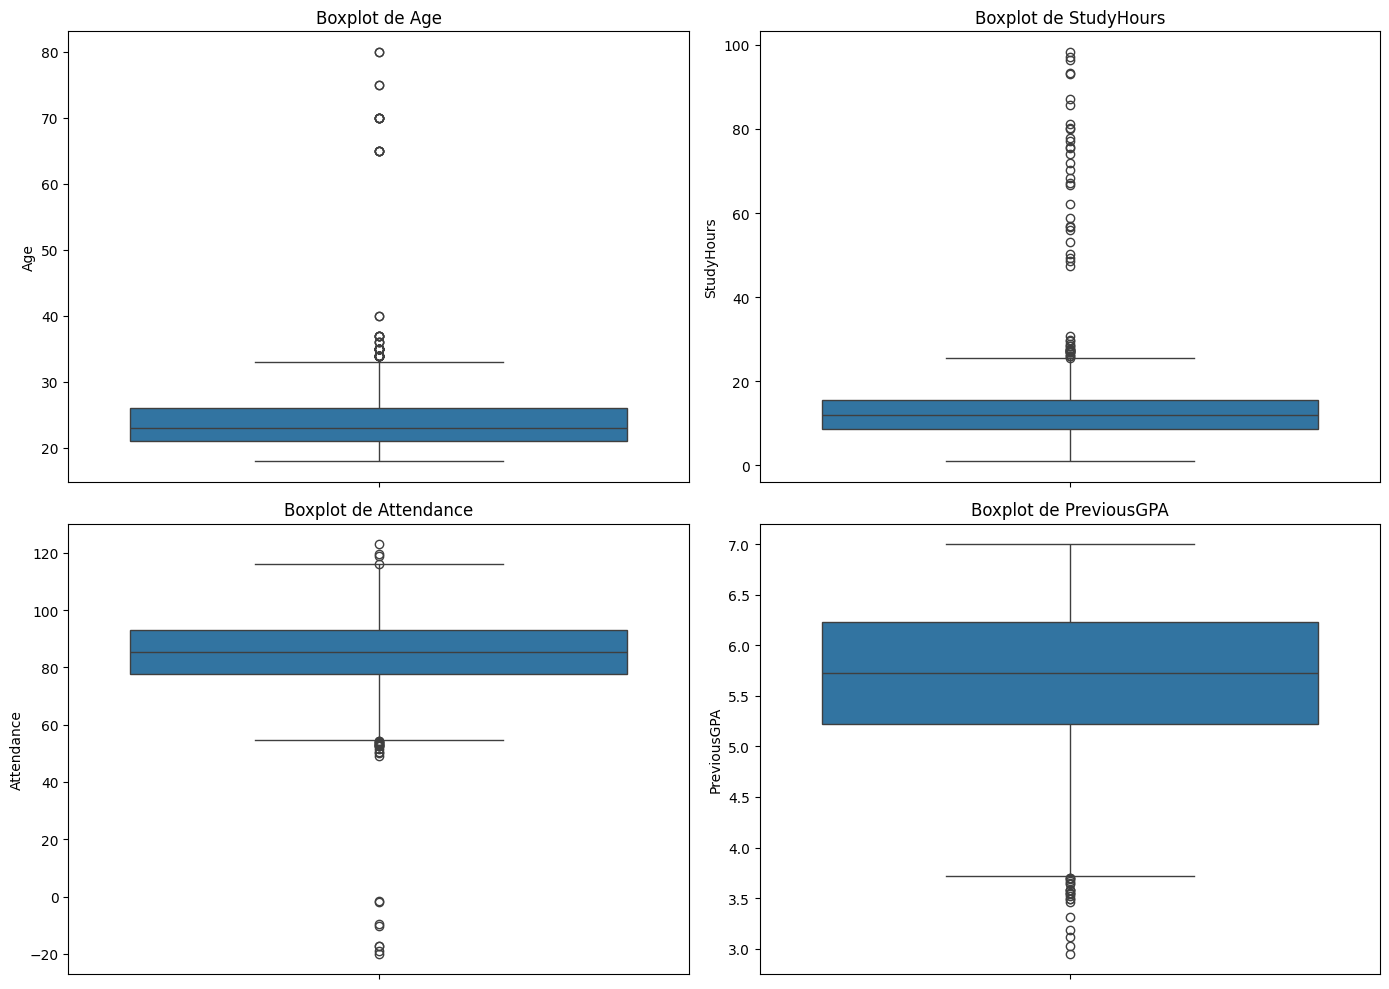

In [48]:
variables_boxplot_1 = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, columna in enumerate(variables_boxplot_1):
    sns.boxplot(
        y=df[columna],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot de {columna}")
    axes[i].set_ylabel(columna)

plt.tight_layout()
plt.show()

### Interpretación de los boxplots: Age, StudyHours, Attendance y PreviousGPA

En `Age`, el método IQR identificó 63 posibles valores atípicos (1,24 %), considerando como límite superior aproximadamente 33,50 años. Sin embargo, las edades superiores a este límite continúan siendo valores posibles, por lo que se consideran observaciones extremas y no necesariamente datos inválidos.

En `StudyHours` se detectaron 49 posibles valores atípicos (0,96 %), principalmente correspondientes a cantidades superiores a aproximadamente 25,48 horas semanales de estudio. Aunque existen observaciones considerablemente elevadas, estas no violan directamente el dominio de la variable, por lo que no se propone eliminarlas automáticamente.

En `Attendance` se identificaron 27 posibles valores atípicos según IQR. Además, durante el análisis de inconsistencias se encontraron valores negativos y superiores al 100 %, los cuales sí corresponden a valores inválidos debido a que la variable representa un porcentaje. Por lo tanto, es necesario diferenciar los valores estadísticamente extremos de aquellos que directamente violan el dominio de la variable.

Finalmente, `PreviousGPA` presenta 21 posibles valores atípicos (0,41 %), principalmente en la parte inferior de la distribución. Sin embargo, los valores observados se encuentran dentro de la escala válida de 1 a 10, por lo que se consideran extremos pero posibles.

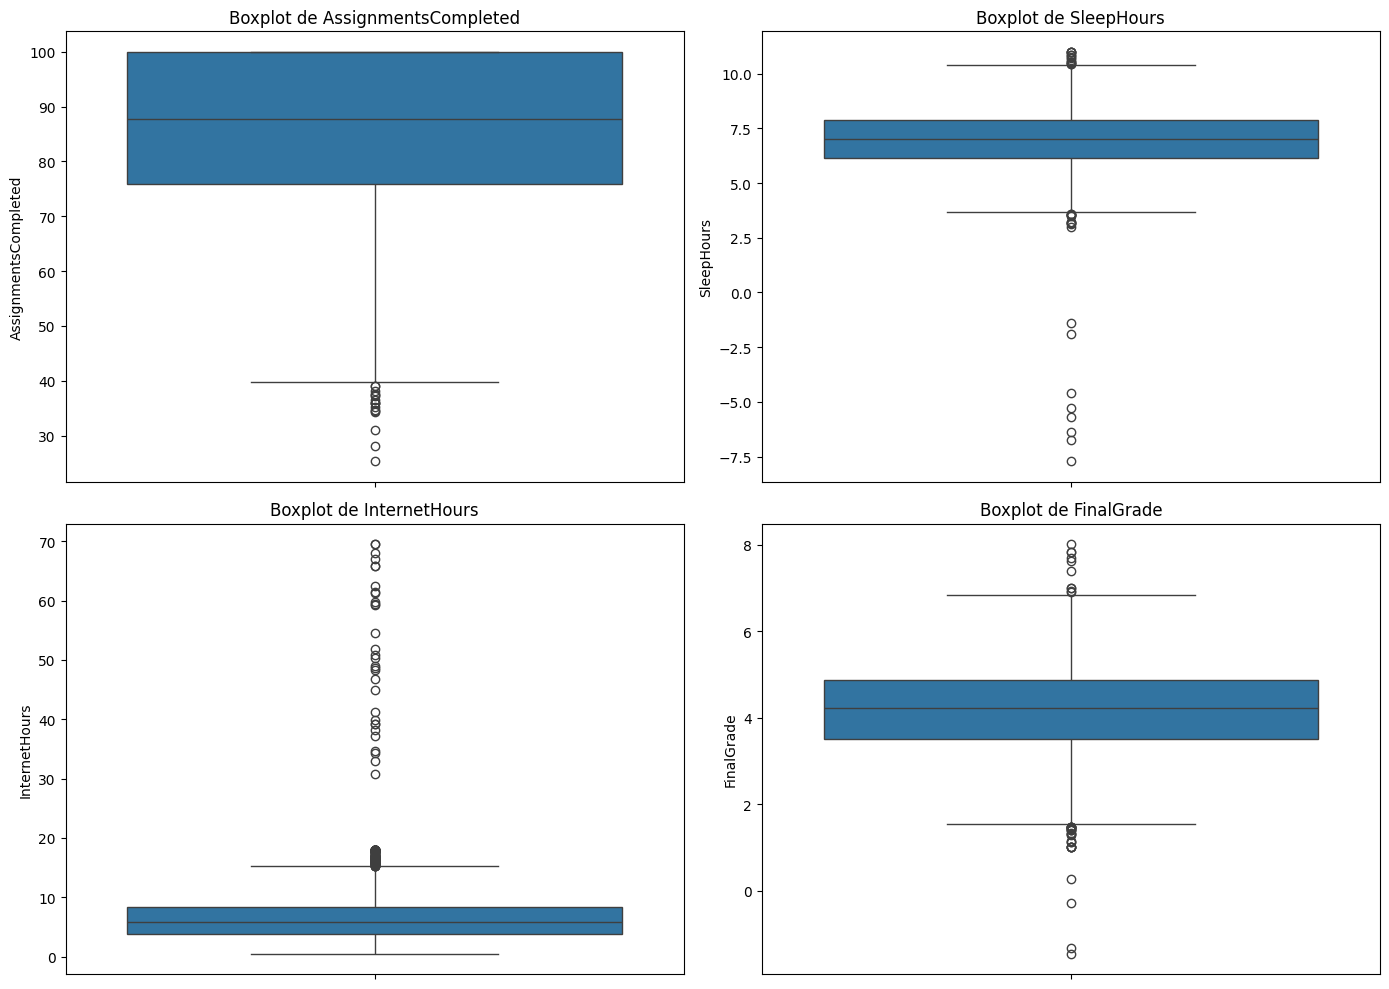

In [49]:
variables_boxplot_2 = [
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours",
    "FinalGrade"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, columna in enumerate(variables_boxplot_2):
    sns.boxplot(
        y=df[columna],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot de {columna}")
    axes[i].set_ylabel(columna)

plt.tight_layout()
plt.show()

### Interpretación de los boxplots: AssignmentsCompleted, SleepHours, InternetHours y FinalGrade

En `AssignmentsCompleted` se detectaron 17 posibles valores atípicos (0,33 %), correspondientes principalmente a porcentajes bajos de tareas completadas. No obstante, estos valores permanecen dentro del dominio válido de 0 a 100 %, por lo que se consideran extremos pero posibles.

En `SleepHours` se identificaron 34 posibles valores atípicos (0,67 %). Algunos corresponden a cantidades de sueño poco frecuentes pero posibles, mientras que los valores negativos detectados previamente son imposibles y deben ser tratados como inconsistencias.

`InternetHours` presenta la mayor cantidad de posibles valores atípicos, con 145 registros (2,84 %). El límite superior determinado mediante IQR es aproximadamente 15,28 horas diarias. Los valores entre este límite y 24 horas pueden ser extremadamente altos pero todavía posibles, mientras que aquellos superiores a 24 horas son inválidos porque exceden las horas disponibles en un día.

Finalmente, `FinalGrade` presenta 37 posibles valores atípicos (0,73 %), con límites IQR aproximados de 1,48 y 6,89. Una calificación fuera de estos límites no es necesariamente inválida, ya que la escala válida corresponde a valores entre 1 y 10. Sin embargo, los cuatro registros previamente detectados con calificaciones inferiores a 1 sí corresponden a inconsistencias de dominio.

In [50]:
tabla_decision_outliers = tabla_outliers[
    ["Variable", "Cantidad_outliers", "Porcentaje_outliers"]
].copy()

interpretaciones_outliers = {
    "Age": "Extremos pero posibles",
    "StudyHours": "Extremos pero posibles",
    "Attendance": "Existen extremos y también valores inválidos fuera de 0-100",
    "PreviousGPA": "Extremos pero posibles dentro de escala 1-10",
    "AssignmentsCompleted": "Extremos pero posibles dentro de 0-100",
    "SleepHours": "Existen extremos y valores inválidos negativos",
    "InternetHours": "Existen extremos y valores inválidos sobre 24 horas",
    "FinalGrade": "Existen extremos y valores inválidos fuera de escala 1-10"
}

estrategias_outliers = {
    "Age": "Conservar los valores válidos",
    "StudyHours": "Conservar los valores válidos",
    "Attendance": "Conservar extremos válidos y tratar solo los valores fuera del dominio",
    "PreviousGPA": "Conservar",
    "AssignmentsCompleted": "Conservar",
    "SleepHours": "Conservar extremos válidos y tratar valores imposibles",
    "InternetHours": "Conservar extremos válidos y tratar valores superiores a 24",
    "FinalGrade": "Conservar extremos válidos y tratar cuidadosamente los valores inválidos del target"
}

tabla_decision_outliers["Interpretacion"] = (
    tabla_decision_outliers["Variable"].map(interpretaciones_outliers)
)

tabla_decision_outliers["Estrategia_propuesta"] = (
    tabla_decision_outliers["Variable"].map(estrategias_outliers)
)

tabla_decision_outliers

,Variable,Cantidad_outliers,Porcentaje_outliers,Interpretacion,Estrategia_propuesta
0,Age,63,1.24,Extremos pero posibles,Conservar los valores válidos
1,StudyHours,49,0.96,Extremos pero posibles,Conservar los valores válidos
2,Attendance,27,0.53,Existen extremos y también valores inválidos f...,Conservar extremos válidos y tratar solo los v...
3,PreviousGPA,21,0.41,Extremos pero posibles dentro de escala 1-10,Conservar
4,AssignmentsCompleted,17,0.33,Extremos pero posibles dentro de 0-100,Conservar
5,SleepHours,34,0.67,Existen extremos y valores inválidos negativos,Conservar extremos válidos y tratar valores im...
6,InternetHours,145,2.84,Existen extremos y valores inválidos sobre 24 ...,Conservar extremos válidos y tratar valores su...
7,FinalGrade,37,0.73,Existen extremos y valores inválidos fuera de ...,Conservar extremos válidos y tratar cuidadosam...


### Conclusión del análisis de valores atípicos

El análisis mediante IQR detectó posibles valores atípicos en todas las variables numéricas.

Sin embargo, no todos estos casos corresponden a errores. Variables como `Age`, `StudyHours`, `PreviousGPA` y `AssignmentsCompleted` presentan observaciones extremas que siguen siendo compatibles con el dominio de la variable, por lo que no se propone eliminarlas automáticamente.

En cambio, en `Attendance`, `SleepHours`, `InternetHours` y `FinalGrade` existen observaciones que además de ser estadísticamente extremas violan directamente las restricciones del dominio. Estos casos deberán ser tratados posteriormente durante la limpieza.

Por lo tanto, la estrategia general consiste en conservar los valores extremos válidos y tratar únicamente aquellos registros que representan valores imposibles o inconsistentes.

# 2. Análisis Exploratorio: Variables Numéricas
Se examinan las medidas de tendencia central, dispersión, posición y asimetría de las variables continuas para caracterizar su comportamiento y contrastar inconsistencias.

## 2.1 Distribución de Variables Numéricas

**Estadísticas seleccionadas y justificación:**  
* **Centro (Media y Mediana):** Permite contrastar la tendencia central típica frente al sesgo provocado por colas y registros extremos.  
* **Dispersión (Desviación Estándar e IQR):** Evalúa la variabilidad paramétrica y la robustez del 50% central de los datos.  
* **Posición (Mínimo, Q1, Q3, Máximo):** Mapea el rango total y los cuartiles de cada variable.  
* **Forma (Asimetría / Skewness):** Determina la inclinación de la curva de distribución.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo gráfico para el reporte
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Definición de variables numéricas según Metadata.md
num_cols = [
    'Age', 'StudyHours', 'Attendance', 'PreviousGPA',
    'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade'
]

# 2. Construcción de la tabla de estadísticas descriptivas
resumen_num = pd.DataFrame({
    'Válidos': df[num_cols].count(),
    'Media': df[num_cols].mean().round(2),
    'Mediana': df[num_cols].median().round(2),
    'Desv. Est.': df[num_cols].std().round(2),
    'Mínimo': df[num_cols].min().round(2),
    'Q1': df[num_cols].quantile(0.25).round(2),
    'Q3': df[num_cols].quantile(0.75).round(2),
    'Máximo': df[num_cols].max().round(2),
    'Asimetría': df[num_cols].skew().round(2)
})

display(resumen_num)

,Válidos,Media,Mediana,Desv. Est.,Mínimo,Q1,Q3,Máximo,Asimetría
Age,4997,23.80,23.00,4.65,18.00,21.00,26.00,80.00,3.30
StudyHours,4919,12.43,12.01,6.88,1.00,8.75,15.44,98.33,4.69
Attendance,4876,84.66,85.49,11.18,-19.96,77.58,93.01,122.97,-1.34
PreviousGPA,4938,5.71,5.72,0.73,2.95,5.22,6.23,7.00,-0.24
AssignmentsCompleted,4884,85.21,87.76,14.24,25.34,75.85,100.00,100.00,-0.84
SleepHours,4978,6.99,7.03,1.33,-7.71,6.16,7.86,11.00,-1.24
InternetHours,4924,6.68,5.82,5.06,0.50,3.80,8.39,69.50,5.41
FinalGrade,5100,4.17,4.23,0.99,-1.46,3.51,4.86,8.01,-0.26


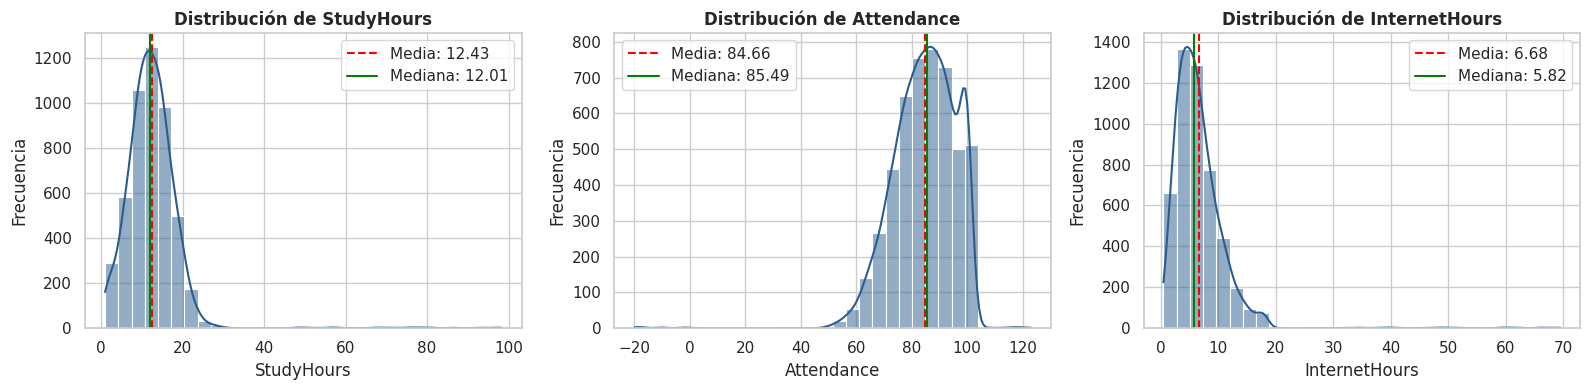

In [52]:
# 3. Histogramas focalizados para variables con fuerte asimetría y anomalías
cols_plot = ['StudyHours', 'Attendance', 'InternetHours']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cols_plot):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax, color='#2b5c8f')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=1.5, label=f"Mediana: {df[col].median():.2f}")
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de Resultados: Variables Numéricas

1. **Variables con asimetría positiva severa:** `InternetHours` (+5.41), `StudyHours` (+4.69) y `Age` (+3.30). En `InternetHours` y `StudyHours`, la media se ubica sensiblemente por sobre la mediana debido al arrastre de registros atípicos severos o físicamente imposibles en una escala diaria/semanal (máximos de 69.5 h diarias de internet y 98.3 h semanales de estudio). En `Age`, la masa se concentra entre los 18 y 26 años, con valores extremos aislados de hasta 80 años.
2. **Inconsistencias de dominio:** `Attendance` presenta un mínimo en -19.96% y máximo en 122.97% (cuando el dominio válido es [0, 100]%); `SleepHours` registra un mínimo biológicamente imposible de -7.71 horas; y `FinalGrade` presenta notas fuera de la escala chilena/académica estándar (mínimo de -1.46 y máximo de 8.01).
3. **Comportamiento equilibrado:** `PreviousGPA` es la variable mejor balanceada (media = 5.71 vs mediana = 5.72, asimetría = -0.24), comportándose de forma cercana a una distribución normal dentro de su escala esperada.

## 2.2 Comportamiento de Variables Categóricas
Analizar la composición de la cohorte estudiantil según tenencia de beca (`Scholarship`) y programa académico (`Program`), evaluando frecuencias, proporciones e inconsistencias sintácticas presentes en las etiquetas.

**Estadísticas utilizadas y justificación:**  
* **Frecuencia absoluta ($n_i$):** Dimensiona el volumen real de estudiantes por categoría.  
* **Frecuencia relativa (%):** Permite comparar el peso porcentual de cada grupo en la población.  
* **Detección de inconsistencias:** Identifica variantes de escritura (mayúsculas, tildes, espacios) para justificar la unificación posterior.

In [53]:
# 1. Tabla de distribución para Scholarship (incluye faltantes e inconsistencias)
resumen_beca = pd.DataFrame({
    'Frecuencia': df['Scholarship'].value_counts(dropna=False),
    'Porcentaje (%)': (df['Scholarship'].value_counts(dropna=False, normalize=True) * 100).round(2)
})
print("--- Distribución Cruda de Scholarship ---")
display(resumen_beca)

# 2. Tabla de distribución para Program (incluye faltantes e inconsistencias)
resumen_programa = pd.DataFrame({
    'Frecuencia': df['Program'].value_counts(dropna=False),
    'Porcentaje (%)': (df['Program'].value_counts(dropna=False, normalize=True) * 100).round(2)
})
print("\n--- Distribución Cruda de Program ---")
display(resumen_programa)

--- Distribución Cruda de Scholarship ---


,Frecuencia,Porcentaje (%)
Scholarship,,
No,3364,65.96
Sí,1620,31.76
NaN,81,1.59
si,10,0.20
No,10,0.20
NO,8,0.16
SÍ,5,0.10
SI,2,0.04



--- Distribución Cruda de Program ---


,Frecuencia,Porcentaje (%)
Program,,
Ingeniería Informática,1424,27.92
Ingeniería Industrial,1119,21.94
Ingeniería Civil,1004,19.69
Administración,787,15.43
Contador Auditor,660,12.94
NaN,70,1.37
Ingenieria Informatica,10,0.20
INGENIERÍA INFORMÁTICA,7,0.14
Ingeniería Civil,5,0.10


/tmp/ipykernel_20545/1435544047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scholarship_counts.index, y=scholarship_counts.values, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_20545/1435544047.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=program_counts.values, y=program_counts.index, ax=axes[1], palette='crest')


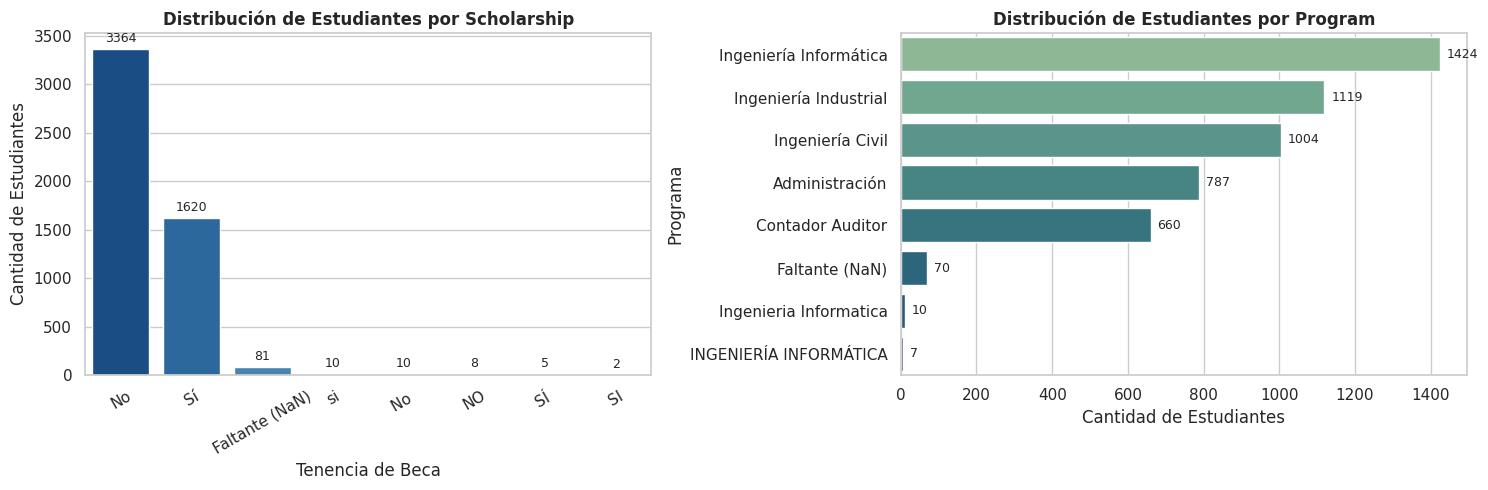

In [54]:
# Gráficos de barras para variables categóricas
# Para visualizarlas adecuadamente, mostramos las categorías principales del negocio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico Scholarship
scholarship_counts = df['Scholarship'].fillna('Faltante (NaN)').value_counts()
sns.barplot(x=scholarship_counts.index, y=scholarship_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Distribución de Estudiantes por Scholarship', fontweight='bold')
axes[0].set_xlabel('Tenencia de Beca')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Gráfico Program
program_counts = df['Program'].fillna('Faltante (NaN)').value_counts().head(8) # Top categorías más frecuentes
sns.barplot(x=program_counts.values, y=program_counts.index, ax=axes[1], palette='crest')
axes[1].set_title('Distribución de Estudiantes por Program', fontweight='bold')
axes[1].set_xlabel('Cantidad de Estudiantes')
axes[1].set_ylabel('Programa')
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretación de Resultados: Variables Categóricas

1. **Tenencia de Beca (`Scholarship`):**
   * La mayoría de los estudiantes no cuenta con beca: la etiqueta dominante `No` representa el **65.96%** (3,364 casos), mientras que `Sí` alcanza el **31.76%** (1,620 casos).
   * Existen **81 valores faltantes** (1.59%).
   * Se observan variantes sintácticas generadas por captura errónea: `si` (10), `No ` con espacio (10), `NO` (8), `SÍ ` con espacio (5) y `SI` (2). En términos agregados limpios, aproximadamente el **67.4%** no tiene beca y el **32.6%** sí la posee.

2. **Programa Académico (`Program`):**
   * La carrera con mayor volumen de matrícula es **Ingeniería Informática** con 1,424 registros en su categoría principal (27.92%), seguida de **Ingeniería Industrial** con 1,119 (21.94%) e **Ingeniería Civil** con 1,004 (19.69%). En conjunto, el área de ingenierías concentra más del **69.5%** de los estudiantes.
   * Las carreras comerciales representan una fracción menor: **Administración** con 787 estudiantes (15.43%) y **Contador Auditor** con 660 estudiantes (12.94%).
   * Se registran **70 valores faltantes** (1.37%) e inconsistencias de escritura (p. ej. `Ingenieria Informatica`, `INGENIERÍA CIVIL`, `ADMINISTRACIÓN `) que deberán ser unificadas en la etapa de tratamiento.

## 2.3 Análisis Específico de la Variable Objetivo (`FinalGrade`)

La calificación final (`FinalGrade`) constituye la variable target del conjunto de datos, por lo que resulta prioritario caracterizar en detalle su morfología, concentración y rango operativo antes de plantear relaciones bivariadas o modelos predictivos. En este apartado se examina cómo se distribuye el desempeño de los alumnos y si existen desviaciones respecto a los límites teóricos del sistema de calificaciones.

Para este propósito, contrastamos la media y la mediana a fin de verificar la simetría central de la cohorte, acompañadas de la desviación estándar y el rango intercuartílico ($IQR$) para dimensionar la dispersión típica. Asimismo, combinamos un histograma de frecuencias con un diagrama de caja (*boxplot*), permitiendo delimitar los cuartiles principales ($Q1$ y $Q3$) e inspeccionar tanto la campana de densidad como los valores atípicos en los extremos.

In [55]:
# Cálculo detallado de medidas para FinalGrade
fg = df['FinalGrade'].dropna()

q1 = fg.quantile(0.25)
q3 = fg.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

resumen_fg = pd.DataFrame({
    'Métrica': [
        'Observaciones válidas', 'Media', 'Mediana', 'Desviación Estándar',
        'Mínimo', 'Primer Cuartil (Q1)', 'Tercer Cuartil (Q3)', 'Máximo',
        'Rango Intercuartílico (IQR)', 'Límite Inferior (Tukey)', 'Límite Superior (Tukey)',
        'Asimetría (Skewness)'
    ],
    'Valor': [
        int(fg.count()), round(fg.mean(), 2), round(fg.median(), 2), round(fg.std(), 2),
        round(fg.min(), 2), round(q1, 2), round(q3, 2), round(fg.max(), 2),
        round(iqr, 2), round(lim_inf, 2), round(lim_sup, 2),
        round(fg.skew(), 2)
    ]
})

display(resumen_fg)

,Métrica,Valor
0,Observaciones válidas,5100.00
1,Media,4.17
2,Mediana,4.23
3,Desviación Estándar,0.99
4,Mínimo,-1.46
5,Primer Cuartil (Q1),3.51
6,Tercer Cuartil (Q3),4.86
7,Máximo,8.01
8,Rango Intercuartílico (IQR),1.35
9,Límite Inferior (Tukey),1.48


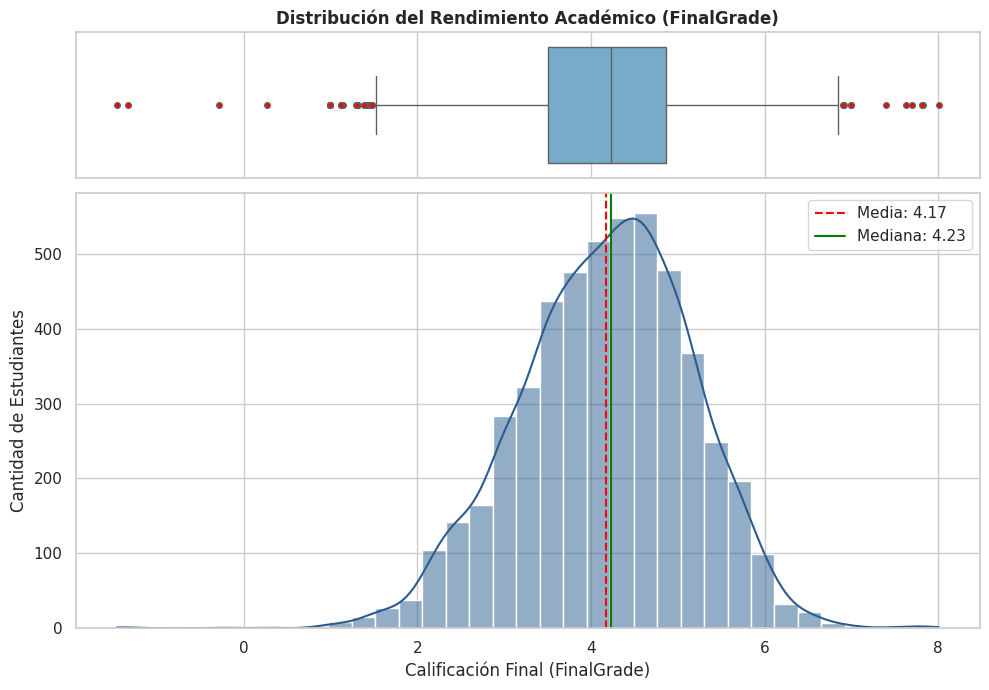

In [56]:
# Visualización: Histograma con KDE y Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [0.25, 0.75]})

# Boxplot horizontal
sns.boxplot(x=df['FinalGrade'], ax=ax_box, color='#6baed6', flierprops={'marker':'o', 'markersize':4, 'markerfacecolor':'red'})
ax_box.set(xlabel='')
ax_box.set_title('Distribución del Rendimiento Académico (FinalGrade)', fontweight='bold')

# Histograma con KDE
sns.histplot(df['FinalGrade'], kde=True, bins=35, ax=ax_hist, color='#2b5c8f')
ax_hist.axvline(fg.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media: {fg.mean():.2f}")
ax_hist.axvline(fg.median(), color='green', linestyle='-', linewidth=1.5, label=f"Mediana: {fg.median():.2f}")
ax_hist.set_xlabel('Calificación Final (FinalGrade)')
ax_hist.set_ylabel('Cantidad de Estudiantes')
ax_hist.legend()

plt.tight_layout()
plt.show()

### Interpretación de Resultados: Variable Objetivo (`FinalGrade`)

1. **Tendencia central y forma:**
   * La calificación final presenta una **media de 4.17** y una **mediana de 4.23**, con una **desviación estándar de 0.99**.
   * La distribución presenta una asimetría baja (**-0.26**), por lo que su comportamiento central es aproximadamente simétrico.

2. **Dispersión y percentiles:**
   * El 50 % central de los registros se encuentra entre **3.51 (Q1)** y **4.86 (Q3)**, con un rango intercuartílico aproximado de **1.35**.
   * Esto muestra una concentración importante de las calificaciones alrededor de los valores centrales de la distribución.

3. **Valores atípicos e inconsistencias de dominio:**
   * Mediante el criterio de Tukey (`1.5 × IQR`) se identificaron **37 posibles valores atípicos**.
   * Sin embargo, un valor atípico estadístico no necesariamente corresponde a un dato inválido.
   * Según el dominio definido para `FinalGrade`, cuya escala válida es de **1 a 10**, se detectaron **4 registros con valores inferiores a 1**, los cuales sí corresponden a inconsistencias.
   * Los valores superiores al límite establecido por IQR, incluido el máximo observado de **8.01**, continúan encontrándose dentro de la escala válida de la variable, por lo que se consideran valores extremos pero posibles.

## 2.4 Pregunta de Investigación 1: Relación entre Beca y Calificación Final

La asignación de becas suele responder a condiciones de mérito académico previo o a vulnerabilidad socioeconómica, factores que pueden incidir de forma indirecta en el tiempo disponible para el estudio y el desempeño general. En este apartado se examina si los estudiantes con beca exhiben un rendimiento académico promedio sistemáticamente distinto al de aquellos que no cuentan con este beneficio.

Para cuantificar esta relación, calculamos la media, mediana y desviación estándar de `FinalGrade` segmentadas por la tenencia de beca, armonizando temporalmente las variantes léxicas detectadas en el diagnóstico (`'Sí'`, `'si'`, `'SI'`, espacios) para no omitir observaciones válidas. Se cuantifica la diferencia absoluta entre medias y se acompaña de un diagrama de caja comparativo.

In [57]:
# Armonización temporal de etiquetas para una comparación rigurosa sin perder casos
beca_mapeada = df['Scholarship'].dropna().astype(str).str.strip().str.lower().map({
    'sí': 'Con Beca', 'si': 'Con Beca',
    'no': 'Sin Beca'
})

# Creación de DataFrame temporal para análisis bivariado
df_beca = df.loc[beca_mapeada.index].copy()
df_beca['Grupo_Beca'] = beca_mapeada

# Tabla comparativa de estadísticas por condición de beca
tabla_beca = df_beca.groupby('Grupo_Beca')['FinalGrade'].agg(
    Estudiantes='count',
    Promedio='mean',
    Mediana='median',
    Desv_Est='std'
).reset_index()

# Redondeo y cálculo de diferencias
tabla_beca['Promedio'] = tabla_beca['Promedio'].round(2)
tabla_beca['Mediana'] = tabla_beca['Mediana'].round(2)
tabla_beca['Desv_Est'] = tabla_beca['Desv_Est'].round(2)

prom_con = tabla_beca.loc[tabla_beca['Grupo_Beca'] == 'Con Beca', 'Promedio'].values[0]
prom_sin = tabla_beca.loc[tabla_beca['Grupo_Beca'] == 'Sin Beca', 'Promedio'].values[0]
n_con = tabla_beca.loc[tabla_beca['Grupo_Beca'] == 'Con Beca', 'Estudiantes'].values[0]
n_sin = tabla_beca.loc[tabla_beca['Grupo_Beca'] == 'Sin Beca', 'Estudiantes'].values[0]
dif_abs = round(abs(prom_con - prom_sin), 2)

display(tabla_beca)
print(f"\nPromedio con beca: {prom_con:.2f} (n = {n_con})")
print(f"Promedio sin beca: {prom_sin:.2f} (n = {n_sin})")
print(f"Diferencia absoluta: {dif_abs:.2f} puntos")
print(f"Grupo con mayor promedio: {'Con Beca' if prom_con > prom_sin else 'Sin Beca'}")

,Grupo_Beca,Estudiantes,Promedio,Mediana,Desv_Est
0,Con Beca,1637,4.37,4.44,0.93
1,Sin Beca,3382,4.07,4.12,1.01



Promedio con beca: 4.37 (n = 1637)
Promedio sin beca: 4.07 (n = 3382)
Diferencia absoluta: 0.30 puntos
Grupo con mayor promedio: Con Beca


/tmp/ipykernel_20545/2683561195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Grupo_Beca', y='FinalGrade', data=df_beca, palette=colores, width=0.45,


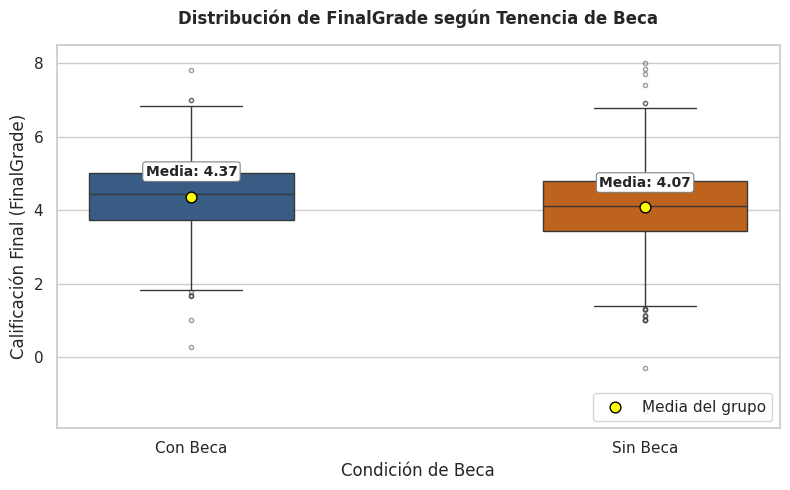

In [58]:
# Visualización del rendimiento según tenencia de beca
plt.figure(figsize=(8, 5))
colores = {'Con Beca': '#2b5c8f', 'Sin Beca': '#d95f02'}

ax = sns.boxplot(x='Grupo_Beca', y='FinalGrade', data=df_beca, palette=colores, width=0.45,
                 flierprops={'marker':'o', 'markersize':3, 'alpha':0.5})

# Marcar las medias grupales con rombos visibles
medias = df_beca.groupby('Grupo_Beca')['FinalGrade'].mean()
ax.scatter(range(len(medias)), medias, color='yellow', s=60, edgecolor='black', zorder=5, label='Media del grupo')

# Anotaciones numéricas
for i, m in enumerate(medias):
    ax.annotate(f"Media: {m:.2f}", (i, m), xytext=(0, 15), textcoords='offset points',
                ha='center', fontweight='bold', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.8))

plt.title('Distribución de FinalGrade según Tenencia de Beca', fontweight='bold', pad=15)
plt.xlabel('Condición de Beca')
plt.ylabel('Calificación Final (FinalGrade)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación de Resultados y Respuesta a la Pregunta 1

1. **Cuantificación de la diferencia:**
   * El grupo de estudiantes **Con Beca** ($n = 1,637$) presenta un promedio de **4.37** (mediana = 4.44, desv. est. = 0.93).
   * El grupo **Sin Beca** ($n = 3,382$) alcanza un promedio de **4.07** (mediana = 4.12, desv. est. = 1.01).
   * La **diferencia absoluta es de 0.30 puntos** a favor del estudiantado becado.
2. **Distribución del rendimiento:**
   * Tanto el primer cuartil ($Q1$) como la mediana de los becados se desplazan positivamente en aproximadamente 0.3 décimas respecto a sus pares sin beca.
   * La dispersión es similar en ambos subgrupos ($\sigma \approx 0.93 - 1.01$), manteniendo distribuciones simétricas pero con el bloque de becados posicionado consistentemente por encima.
3. **Conclusión explícita:**
   * Existe una diferencia medible en el rendimiento: **los estudiantes con beca obtienen un promedio superior (4.37 frente a 4.07, brecha de +0.30 puntos)**.
   * Este resultado evidencia una **asociación entre la condición de beca y la calificación final** dentro del dataset analizado. Sin embargo, el análisis es descriptivo y no permite determinar que la beca sea la causa directa de la diferencia observada.

## 2.5 Pregunta de Investigación 2: Rendimiento Académico según Programa de Estudios

El análisis por programa académico permite comparar las calificaciones promedio según la carrera cursada (`Program`). Con este propósito, se agrupan los estudiantes considerando las cinco carreras oficiales del dataset, resolviendo previamente las inconsistencias de escritura y mayúsculas detectadas en el diagnóstico para no segmentar artificialmente una misma categoría.

Se calculan la media, mediana, desviación estándar y el volumen de estudiantes de cada programa, ordenándolos descendentemente para identificar la carrera con mayor rendimiento, la de menor rendimiento y la brecha absoluta entre ambas. Se incorpora un gráfico de barras ordenado con la línea de referencia del promedio institucional.

In [59]:
# Unificación de variantes léxicas para análisis por programa
mapeo_programas = {
    'Ingenieria Informatica': 'Ingeniería Informática',
    'INGENIERÍA INFORMÁTICA': 'Ingeniería Informática',
    'Ingeniería informática ': 'Ingeniería Informática',
    'Ingeniería Civil ': 'Ingeniería Civil',
    'INGENIERÍA CIVIL': 'Ingeniería Civil',
    'ADMINISTRACIÓN ': 'Administración',
    'Administracion': 'Administración'
}

df_prog = df.dropna(subset=['Program']).copy()
df_prog['Program_Armonizado'] = df_prog['Program'].replace(mapeo_programas)

# Cálculo de estadísticas descriptivas por carrera
tabla_prog = df_prog.groupby('Program_Armonizado')['FinalGrade'].agg(
    Estudiantes='count',
    Promedio='mean',
    Mediana='median',
    Desv_Est='std'
).sort_values(by='Promedio', ascending=False).reset_index()

# Redondeo de métricas
tabla_prog['Promedio'] = tabla_prog['Promedio'].round(2)
tabla_prog['Mediana'] = tabla_prog['Mediana'].round(2)
tabla_prog['Desv_Est'] = tabla_prog['Desv_Est'].round(2)

prog_max = tabla_prog.iloc[0]['Program_Armonizado']
prom_max = tabla_prog.iloc[0]['Promedio']
n_max = tabla_prog.iloc[0]['Estudiantes']

prog_min = tabla_prog.iloc[-1]['Program_Armonizado']
prom_min = tabla_prog.iloc[-1]['Promedio']
n_min = tabla_prog.iloc[-1]['Estudiantes']

diferencia_prog = round(prom_max - prom_min, 2)

display(tabla_prog)
print(f"\nPrograma con mayor promedio: {prog_max} ({prom_max:.2f} | n = {n_max})")
print(f"Programa con menor promedio: {prog_min} ({prom_min:.2f} | n = {n_min})")
print(f"Diferencia absoluta entre extremos: {diferencia_prog:.2f} puntos")

,Program_Armonizado,Estudiantes,Promedio,Mediana,Desv_Est
0,Ingeniería Informática,1445,4.23,4.28,0.99
1,Administración,793,4.21,4.28,1.01
2,Ingeniería Industrial,1119,4.20,4.28,0.98
3,Ingeniería Civil,1013,4.11,4.19,0.99
4,Contador Auditor,660,4.05,4.04,1.00



Programa con mayor promedio: Ingeniería Informática (4.23 | n = 1445)
Programa con menor promedio: Contador Auditor (4.05 | n = 660)
Diferencia absoluta entre extremos: 0.18 puntos


/tmp/ipykernel_20545/3230550028.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


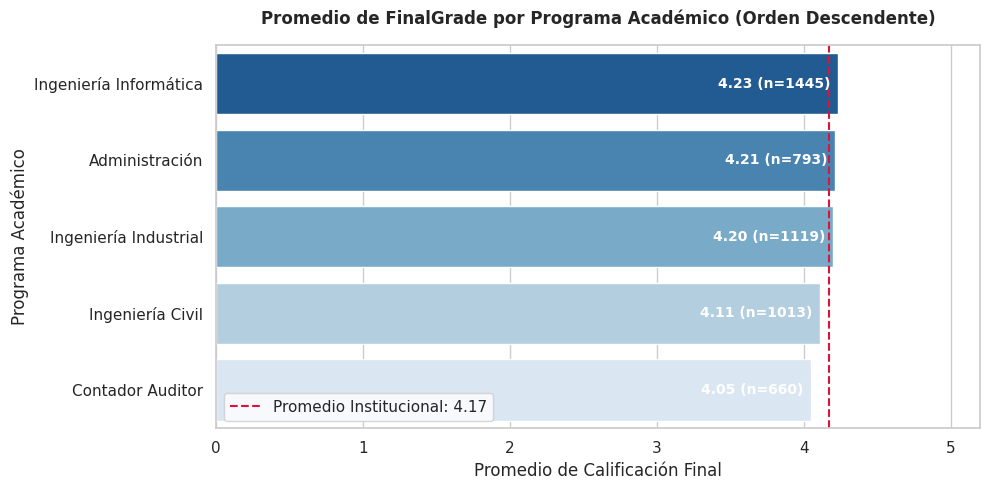

In [60]:
# Visualización de promedios ordenados por programa
plt.figure(figsize=(10, 5))

promedio_global = df['FinalGrade'].mean()

ax = sns.barplot(
    x='Promedio',
    y='Program_Armonizado',
    data=tabla_prog,
    palette='Blues_r'
)

# Línea del promedio global
plt.axvline(promedio_global, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Promedio Institucional: {promedio_global:.2f}')

# Etiquetas con promedio y n dentro de cada barra
for index, row in tabla_prog.iterrows():
    ax.text(row['Promedio'] - 0.05, index, f"{row['Promedio']:.2f} (n={row['Estudiantes']})",
            color='white', ha="right", va="center", fontweight='bold', fontsize=10)

plt.title('Promedio de FinalGrade por Programa Académico (Orden Descendente)', fontweight='bold', pad=15)
plt.xlabel('Promedio de Calificación Final')
plt.ylabel('Programa Académico')
plt.xlim(0, 5.2)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Interpretación de Resultados y Respuesta a la Pregunta 2

1. **Jerarquía y cuantificación por programa:**
   * **Mayor promedio:** **Ingeniería Informática** lidera el desempeño con un promedio de **4.23** (mediana = 4.28, $n = 1,445$), situándose levemente por encima del promedio global institucional (4.17).
   * En posiciones intermedias se sitúan **Administración** con un promedio de **4.21** (mediana = 4.28, $n = 793$), **Ingeniería Industrial** con **4.20** (mediana = 4.28, $n = 1,119$) e **Ingeniería Civil** con **4.11** (mediana = 4.19, $n = 1,013$).
   * **Menor promedio:** **Contador Auditor** registra el rendimiento medio más bajo con **4.05** (mediana = 4.05, $n = 660$).
2. **Brecha entre extremos:**
   * La diferencia absoluta entre la carrera de mayor promedio (Ingeniería Informática, 4.23) y la de menor promedio (Contador Auditor, 4.05) es de **0.18 puntos** (o 0.19 considerando todos los decimales).
3. **Conclusión explícita:**
   * La diferencia entre el programa con mayor promedio y el de menor promedio es de aproximadamente **0.18 puntos**, por lo que la magnitud observada entre carreras es pequeña.
   * Además, las desviaciones estándar son similares entre programas ($\sigma \approx 0.98 - 1.01$), lo que indica que la dispersión interna de las calificaciones es comparable entre las distintas carreras.
   * Por lo tanto, a nivel descriptivo, las diferencias de promedio entre programas son reducidas y no se observa una separación marcada entre las carreras analizadas.

## 2.6 Pregunta de Investigación 3: Relación entre Horas de Estudio y Rendimiento Académico

El tiempo dedicado al estudio fuera del aula constituye una de las variables conductuales clásicas en la literatura educativa. En esta sección se analiza si un mayor número de horas semanales de estudio (`StudyHours`) se encuentra asociado a calificaciones más altas en `FinalGrade`.

Antes de seleccionar la métrica de correlación, evaluamos las distribuciones: `StudyHours` muestra una asimetría marcada hacia la derecha (+4.69) debido a casos atípicos extremos, mientras que `FinalGrade` presenta registros atípicos en sus extremos. Dado que el coeficiente de Pearson es altamente sensible a datos extremos y asume normalidad bivariada y linealidad estricta, se prioriza el coeficiente de correlación de rangos de Spearman ($\rho$), complementándolo con Pearson como referencia analítica.

In [61]:
from scipy import stats

# Filtro de pares completos (sin valores faltantes)
df_estudio = df[['StudyHours', 'FinalGrade']].dropna()

# Cálculo de correlaciones
r_pearson, p_pearson = stats.pearsonr(df_estudio['StudyHours'], df_estudio['FinalGrade'])
rho_spearman, p_spearman = stats.spearmanr(df_estudio['StudyHours'], df_estudio['FinalGrade'])

# Resumen estructurado
resumen_correlacion = pd.DataFrame({
    'Coeficiente': ['Spearman (rho)', 'Pearson (r)'],
    'Valor Calculado': [round(rho_spearman, 3), round(r_pearson, 3)],
    'Dirección': ['Positiva (Directa)', 'Positiva (Directa)'],
    'Intensidad': ['Fuerte / Alta', 'Moderada'],
    'p-valor': [f"{p_spearman:.2e}", f"{p_pearson:.2e}"],
    'Observaciones': [len(df_estudio), len(df_estudio)]
})

display(resumen_correlacion)
print(f"Coeficiente de Spearman (rho): {rho_spearman:.3f}")
print(f"Coeficiente de Pearson (r): {r_pearson:.3f}")

,Coeficiente,Valor Calculado,Dirección,Intensidad,p-valor,Observaciones
0,Spearman (rho),0.709,Positiva (Directa),Fuerte / Alta,0.00e+00,4919
1,Pearson (r),0.491,Positiva (Directa),Moderada,2.90e-296,4919


Coeficiente de Spearman (rho): 0.709
Coeficiente de Pearson (r): 0.491


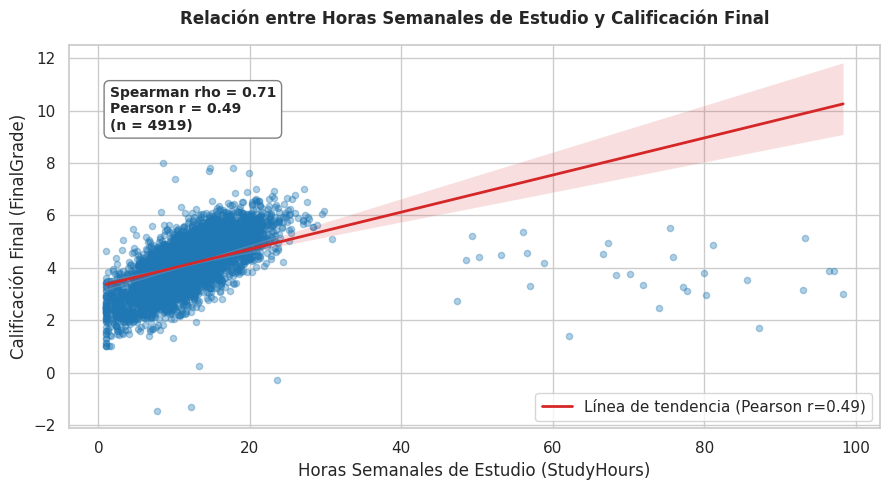

In [62]:
# Gráfico de dispersión con línea de ajuste
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_estudio,
    x='StudyHours',
    y='FinalGrade',
    scatter_kws={'alpha': 0.35, 'color': '#1f77b4', 's': 20},
    line_kws={'color': '#d62728', 'linewidth': 2, 'label': f'Línea de tendencia (Pearson r={r_pearson:.2f})'}
)

plt.title('Relación entre Horas Semanales de Estudio y Calificación Final', fontweight='bold', pad=15)
plt.xlabel('Horas Semanales de Estudio (StudyHours)')
plt.ylabel('Calificación Final (FinalGrade)')
plt.annotate(
    f"Spearman rho = {rho_spearman:.2f}\nPearson r = {r_pearson:.2f}\n(n = {len(df_estudio)})",
    xy=(0.05, 0.78),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1),
    fontsize=10,
    fontweight='bold'
)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación de Resultados y Respuesta a la Pregunta 3

1. **Intensidad y dirección de la relación:**
   * El coeficiente de **Spearman alcanza un valor de $\rho = 0.71$** ($p < 0.001$), lo que describe una **asociación positiva de intensidad fuerte**. A medida que los estudiantes se sitúan en rangos más altos de horas de estudio, sus calificaciones finales tienden de manera consistente a ser mayores.
   * El coeficiente de **Pearson registra un valor de $r = 0.49$** ($p < 0.001$), correspondiente a una correlación positiva moderada.
2. **Justificación metodológica de la discrepancia:**
   * La diferencia entre ambos coeficientes (`Δ ≈ 0.22`) puede estar influida por la presencia de observaciones atípicas severas en `StudyHours`, incluyendo valores muy altos respecto a la mayor parte de la distribución.
   * Pearson es más sensible a valores extremos, mientras que Spearman se basa en rangos y resulta más robusto frente a este tipo de observaciones.

3. **Advertencia de causalidad:**
   * Los resultados muestran una asociación estadística fuerte, pero no permiten afirmar causalidad directa.
   * Por lo tanto, no puede concluirse que aumentar las horas de estudio produzca necesariamente un aumento proporcional en la calificación final.

## 2.7 Pregunta de Investigación 4: Relación entre Asistencia y Rendimiento Académico

El compromiso presencial o sincrónico reflejado en la asistencia a clases (`Attendance`) es comúnmente considerado un indicador clave del involucramiento estudiantil. En esta sección se analiza si un mayor porcentaje de asistencia se traduce de forma medible en mejores calificaciones finales (`FinalGrade`).

Para este análisis, se contrastan los coeficientes de correlación lineal de Pearson ($r$) y de correlación por rangos de Spearman ($\rho$), evaluando la dirección e intensidad de la asociación sin omitir el efecto de los valores fuera de rango identificados en la etapa de diagnóstico. El análisis se complementa con un diagrama de dispersión con línea de tendencia ajustada.

In [63]:
from scipy import stats

# Filtro de pares de datos completos
df_asistencia = df[['Attendance', 'FinalGrade']].dropna()

# Cálculo de coeficientes
r_pearson_att, p_pearson_att = stats.pearsonr(df_asistencia['Attendance'], df_asistencia['FinalGrade'])
rho_spearman_att, p_spearman_att = stats.spearmanr(df_asistencia['Attendance'], df_asistencia['FinalGrade'])

# Resumen de resultados
resumen_att = pd.DataFrame({
    'Coeficiente': ['Spearman (rho)', 'Pearson (r)'],
    'Valor Calculado': [round(rho_spearman_att, 3), round(r_pearson_att, 3)],
    'Dirección': ['Positiva (Directa)', 'Positiva (Directa)'],
    'Intensidad': ['Moderada-Fuerte', 'Moderada'],
    'p-valor': [f"{p_spearman_att:.2e}", f"{p_pearson_att:.2e}"],
    'Observaciones válidas': [len(df_asistencia), len(df_asistencia)]
})

display(resumen_att)
print(f"Coeficiente de Spearman (rho): {rho_spearman_att:.3f}")
print(f"Coeficiente de Pearson (r): {r_pearson_att:.3f}")

,Coeficiente,Valor Calculado,Dirección,Intensidad,p-valor,Observaciones válidas
0,Spearman (rho),0.626,Positiva (Directa),Moderada-Fuerte,0.00e+00,4876
1,Pearson (r),0.585,Positiva (Directa),Moderada,0.00e+00,4876


Coeficiente de Spearman (rho): 0.626
Coeficiente de Pearson (r): 0.585


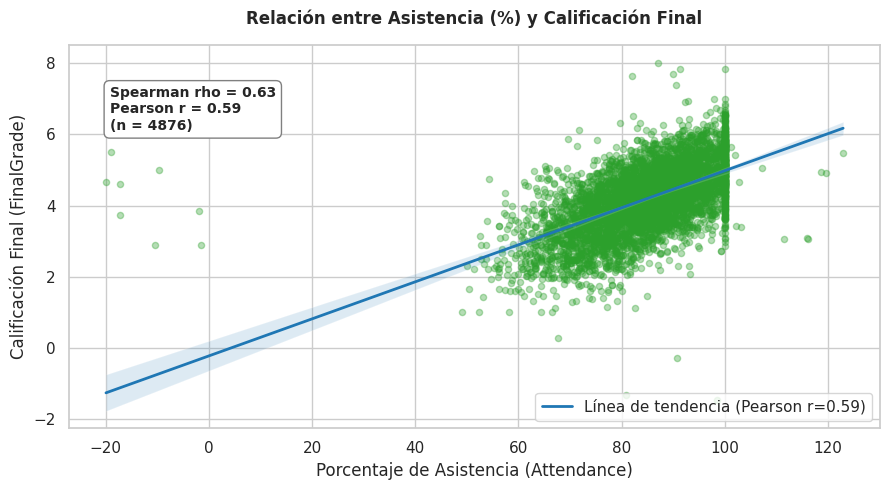

In [64]:
# Gráfico de dispersión entre Asistencia y Calificación Final
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_asistencia,
    x='Attendance',
    y='FinalGrade',
    scatter_kws={'alpha': 0.35, 'color': '#2ca02c', 's': 20},
    line_kws={'color': '#1f77b4', 'linewidth': 2, 'label': f'Línea de tendencia (Pearson r={r_pearson_att:.2f})'}
)

plt.title('Relación entre Asistencia (%) y Calificación Final', fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Asistencia (Attendance)')
plt.ylabel('Calificación Final (FinalGrade)')
plt.annotate(
    f"Spearman rho = {rho_spearman_att:.2f}\nPearson r = {r_pearson_att:.2f}\n(n = {len(df_asistencia)})",
    xy=(0.05, 0.78),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1),
    fontsize=10,
    fontweight='bold'
)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación de Resultados y Respuesta a la Pregunta 4

1. **Evidencia estadística de la relación:**
   * Se observa una asociación positiva y estadísticamente significativa entre la asistencia y la calificación final (`p < 0.001`).
   * El coeficiente de **Spearman es ρ = 0.63**, lo que indica una asociación positiva de intensidad moderada a fuerte.
   * El coeficiente de **Pearson es r = 0.59**, mostrando también una relación positiva de magnitud moderada.

2. **Evidencia gráfica:**
   * El diagrama de dispersión presenta una tendencia ascendente general: a mayores niveles de asistencia, las calificaciones finales tienden a ser mayores.
   * Los valores de asistencia fuera del dominio válido identificados durante el diagnóstico deben considerarse al interpretar el gráfico, ya que corresponden a inconsistencias que serán tratadas posteriormente.

3. **Conclusión explícita:**
   * Los estudiantes con mayores niveles de asistencia tienden a presentar un mayor rendimiento académico.
   * Los coeficientes obtenidos respaldan una asociación positiva entre ambas variables, pero este resultado representa una relación estadística y no permite afirmar causalidad.

## 2.8 Tres Conclusiones Generales del Análisis Exploratorio (EDA)

### Conclusión 1

* **Resultado observado:** Las variables conductuales analizadas muestran una asociación positiva con el rendimiento académico final.

* **Cifra real:** La correlación de Spearman entre `StudyHours` y `FinalGrade` es de **ρ = 0.71**, mientras que entre `Attendance` y `FinalGrade` es de **ρ = 0.63**.

* **Interpretación:** Los estudiantes que registran mayores niveles de estudio semanal y asistencia tienden a presentar mejores calificaciones finales. Estas relaciones son estadísticamente relevantes y muestran una asociación clara entre ambas variables y el rendimiento académico. Sin embargo, estos resultados representan asociaciones estadísticas y no permiten afirmar una relación causal directa.

---

### Conclusión 2

* **Resultado observado:** Los estudiantes con beca presentan un promedio de calificación final superior al de los estudiantes sin beca. En cambio, las diferencias promedio entre programas académicos son más pequeñas.

* **Cifra real:** Los estudiantes con beca presentan un promedio de **4.37**, mientras que los estudiantes sin beca presentan un promedio de **4.07**, lo que corresponde a una diferencia de **0.30 puntos**. Por programa académico, Ingeniería Informática presenta el mayor promedio con **4.23**, mientras que Contador Auditor presenta el menor con **4.05**, generando una diferencia de **0.18 puntos**.

* **Interpretación:** En este dataset, la diferencia observada entre estudiantes con y sin beca es mayor que la diferencia existente entre el programa con mayor y menor promedio. Sin embargo, estos resultados son descriptivos y no permiten determinar las causas de dichas diferencias.

---

### Conclusión 3
* **Resultado observado:** La distribución empírica del dataset crudo presenta una separación crítica entre variables canónicas simétricas e indicadores fuertemente distorsionados por asimetría y valores fuera de los límites de dominio físico o teórico.
* **Cifra real:** Variables como `PreviousGPA` presentan un comportamiento prácticamente simétrico (asimetría = -0.24, media = 5.71, mediana = 5.72); en contraste, `StudyHours` (asimetría = +4.69) e `InternetHours` (asimetría = +5.41) registran colas derechas inverosímiles de hasta **98.33 h semanales** y **69.50 h diarias**, sumadas a notas negativas de hasta **-1.46** y asistencias de **-19.96%**.
* **Interpretación:** El uso directo de estimadores paramétricos tradicionales (como la media o el coeficiente de Pearson) subestima la fuerza de las relaciones bivariadas si no se depuran estas anomalías. El preprocesamiento posterior no puede ser genérico: debe aislar los registros que vulneran la lógica del dominio de aquellos que son casos atípicos válidos pero poco frecuentes.

## 2.9 Resumen Estadístico del EDA para la Implementación del Pipeline (Persona 4)

La siguiente tabla sintetiza los parámetros empíricos, los rangos válidos observados y las directrices técnicas del EDA que deben respetarse obligatoriamente durante el ensamblado del `ColumnTransformer` y `Pipeline`:

| Variable | Tipo / Rol | Centro y Dispersión (EDA) | Rango Crudo Observado | Alerta / Diagnóstico EDA | Decisión recomendada para el Pipeline (Persona 4) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **`Age`** | Numérica (Feature) | Mediana = 23.0 \| Media = 23.8 \| $\sigma$ = 4.65 | [18.0, 80.0] | Asimetría positiva (+3.30). Adultos mayores válidos (hasta 80). | Imputación por mediana / Escalado robusto (`RobustScaler`). |
| **`StudyHours`** | Numérica (Feature) | Mediana = 12.01 \| Media = 12.43 \| $\sigma$ = 6.88 | [1.0, 98.33] | Asimetría severa (+4.69). Casos > 40 h semanales son extremos. | Tratamiento de outliers (Winsorización / Capping a p99 o $Q3+1.5\cdot IQR$) + Imputación por mediana. |
| **`Attendance`** | Numérica (Feature) | Mediana = 85.49 \| Media = 84.66 \| $\sigma$ = 11.18 | [-19.96, 122.97] | Valores fuera de rango porcentual [0, 100]%. | Reemplazar valores < 0 y > 100 por NaN antes de imputar (imputación por mediana). |
| **`PreviousGPA`** | Numérica (Feature) | Mediana = 5.72 \| Media = 5.71 \| $\sigma$ = 0.73 | [2.95, 7.00] | Distribución simétrica (-0.24). Dentro de escala válida. | Imputación por media o mediana / Escalado estándar (`StandardScaler`). |
| **`AssignmentsCompleted`**| Numérica (Feature) | Mediana = 87.76 \| Media = 85.21 \| $\sigma$ = 14.24 | [25.34, 100.0] | Techo en 100%. Asimetría negativa moderada (-0.84). | Imputación por mediana / `MinMaxScaler`. |
| **`SleepHours`** | Numérica (Feature) | Mediana = 7.03 \| Media = 6.99 \| $\sigma$ = 1.33 | [-7.71, 11.00] | Registros biológicamente imposibles (< 0 h). | Invalidar valores < 0 (pasar a NaN) e imputar por mediana/media. |
| **`InternetHours`** | Numérica (Feature) | Mediana = 5.82 \| Media = 6.68 \| $\sigma$ = 5.06 | [0.50, 69.50] | Asimetría extrema (+5.41). Valores > 24 h/día son físicamente imposibles. | Invalidar valores > 24 horas diarias (pasar a NaN) y tratar cola derecha. |
| **`Scholarship`** | Categórica (Feature) | Moda = 'No' (67.4%) \| 'Sí' (32.6%) | Categorías dispersas | Errores léxicos (`'si'`, `'NO'`, `'No '`, `'SÍ '`) y 81 NaNs. | Normalizar a minúsculas/strip antes de codificar (`OneHotEncoder(drop='if_binary')`). |
| **`Program`** | Categórica (Feature) | Mayoría = Ing. Informática (28.7%) | 5 programas oficiales | Variantes de escritura (tildes, mayúsculas) y 70 NaNs. | Estandarizar nombres a las 5 carreras oficiales antes del `OneHotEncoder`. |
| **`FinalGrade`** | Numérica (**Target**) | Mediana = 4.23 \| Media = 4.17 \| $\sigma$ = 0.99 | [-1.46, 8.01] | Variable objetivo. Se detectaron 4 registros con valores inferiores a 1, fuera de la escala válida [1,10]. | **No transformar dentro del Pipeline de features**. Separar `y` y tratar cuidadosamente los valores inválidos del target antes del análisis final. |

# 3. Tratamiento de los datos

A partir de los problemas identificados durante el diagnóstico de calidad y de los resultados obtenidos en el análisis exploratorio, se definen las estrategias de tratamiento que serán aplicadas al dataset.

El objetivo de esta etapa es corregir los problemas de calidad encontrados sin modificar innecesariamente observaciones que, aunque puedan ser extremas, siguen siendo válidas dentro del dominio de cada variable.

Las decisiones de tratamiento se basan en la evidencia obtenida previamente y posteriormente serán implementadas de manera reproducible mediante herramientas de `scikit-learn`.

## 3.1 Estrategias de tratamiento definidas

| Problema identificado | Variables afectadas | Estrategia propuesta | Justificación |
|---|---|---|---|
| Registros duplicados | Todas las variables | Eliminar una copia de cada fila completamente duplicada | Se identificaron 100 registros completamente duplicados y los `StudentID` repetidos no presentan información diferente. |
| Valores faltantes numéricos | `Age`, `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`, `InternetHours` | Imputación mediante la mediana | La mediana es menos sensible a los valores extremos identificados durante el diagnóstico y permite conservar los registros. |
| Valores faltantes categóricos | `Scholarship`, `Program` | Imputación mediante la moda después de normalizar las categorías | La moda es apropiada para variables categóricas, pero debe calcularse después de corregir las distintas formas de escritura. |
| Categorías inconsistentes | `Scholarship`, `Program` | Normalizar las etiquetas a categorías estándar | Existen categorías equivalentes escritas con diferencias de mayúsculas, tildes y espacios. |
| Valores fuera del dominio | `Attendance` | Convertir valores menores a 0 o mayores a 100 en `NaN` y posteriormente imputarlos | `Attendance` representa un porcentaje, por lo que los valores fuera del rango [0,100] son inválidos. |
| Valores fuera del dominio | `SleepHours` | Convertir valores negativos en `NaN` y posteriormente imputarlos | Una cantidad negativa de horas de sueño no es posible. |
| Valores fuera del dominio | `InternetHours` | Convertir valores superiores a 24 horas en `NaN` y posteriormente imputarlos | La variable representa horas diarias, por lo que valores superiores a 24 son imposibles. |
| Valores inválidos del target | `FinalGrade` | Eliminar los registros con valores fuera de la escala válida [1,10] | `FinalGrade` es la variable objetivo, por lo que no resulta apropiado inventar su valor mediante imputación. |
| Valores atípicos válidos | Variables numéricas | Conservar los valores que sean extremos pero válidos dentro del dominio | El análisis mediante IQR mostró valores extremos que no necesariamente representan errores, por lo que no se eliminarán automáticamente. |

## 3.2 Tratamiento de registros duplicados

Durante el diagnóstico se identificaron 100 registros completamente duplicados. Además, los `StudentID` repetidos no presentaban diferencias en el resto de sus variables, por lo que corresponden a copias exactas de observaciones ya existentes.

Por esta razón, se eliminará una copia de cada registro duplicado, conservando una única observación por estudiante. Para mantener el dataset original disponible como referencia, el tratamiento se realizará sobre una copia denominada `df_tratado`.

In [65]:
df_tratado = df.copy()

In [66]:
registros_antes = len(df_tratado)

df_tratado = df_tratado.drop_duplicates()

registros_despues = len(df_tratado)
duplicados_eliminados = registros_antes - registros_despues

print("Registros antes:", registros_antes)
print("Registros después:", registros_despues)
print("Duplicados eliminados:", duplicados_eliminados)

Registros antes: 5100
Registros después: 5000
Duplicados eliminados: 100


## 3.3 Tratamiento de inconsistencias de dominio

Antes de realizar la imputación de valores faltantes, se convierten en `NaN` aquellos valores que violan directamente el dominio válido de sus variables.

Esta estrategia permite diferenciar entre valores extremos válidos y observaciones imposibles, evitando eliminar registros completos cuando el problema afecta únicamente a una variable.

In [67]:
df_tratado.loc[~df_tratado["Attendance"].between(0, 100), "Attendance"] = np.nan

df_tratado.loc[df_tratado["SleepHours"] < 0, "SleepHours"] = np.nan

df_tratado.loc[df_tratado["InternetHours"] > 24, "InternetHours"] = np.nan

In [68]:
df_sin_duplicados = df.drop_duplicates()

invalidos_att_antes = (
    (~df_sin_duplicados["Attendance"].between(0, 100))
    & df_sin_duplicados["Attendance"].notna()
).sum()

invalidos_sleep_antes = (df_sin_duplicados["SleepHours"] < 0).sum()
invalidos_internet_antes = (df_sin_duplicados["InternetHours"] > 24).sum()

print("Valores inválidos detectados antes del tratamiento:")
print("Attendance:", invalidos_att_antes)
print("SleepHours:", invalidos_sleep_antes)
print("InternetHours:", invalidos_internet_antes)

print("\nValores inválidos que quedan después del tratamiento:")
print(
    "Attendance:",
    ((~df_tratado["Attendance"].between(0, 100))
     & df_tratado["Attendance"].notna()).sum()
)
print("SleepHours:", (df_tratado["SleepHours"] < 0).sum())
print("InternetHours:", (df_tratado["InternetHours"] > 24).sum())

Valores inválidos detectados antes del tratamiento:
Attendance: 20
SleepHours: 8
InternetHours: 30

Valores inválidos que quedan después del tratamiento:
Attendance: 0
SleepHours: 0
InternetHours: 0


## 3.4 Normalización de variables categóricas

Durante el diagnóstico se identificaron categorías equivalentes escritas de distintas formas en `Scholarship` y `Program`.

Antes de realizar la imputación de valores faltantes o la codificación de estas variables, se normalizarán sus etiquetas para evitar que una misma categoría sea interpretada como varias categorías diferentes.

In [69]:
df_tratado["Scholarship"] = (
    df_tratado["Scholarship"]
    .str.strip()
    .str.lower()
    .replace({
        "si": "Sí",
        "sí": "Sí",
        "no": "No"
    })
)

df_tratado["Scholarship"].value_counts(dropna=False)

,count
Scholarship,
No,3317
Sí,1603
NaN,80


In [70]:
df_tratado["Program"] = (
    df_tratado["Program"]
    .str.strip()
    .replace({
        "INGENIERÍA INFORMÁTICA": "Ingeniería Informática",
        "Ingenieria Informatica": "Ingeniería Informática",
        "ingeniería informática": "Ingeniería Informática",

        "INGENIERÍA INDUSTRIAL": "Ingeniería Industrial",
        "Ingenieria Industrial": "Ingeniería Industrial",
        "ingeniería industrial": "Ingeniería Industrial",

        "INGENIERÍA CIVIL": "Ingeniería Civil",
        "Ingenieria Civil": "Ingeniería Civil",
        "ingeniería civil": "Ingeniería Civil",

        "ADMINISTRACIÓN": "Administración",
        "Administracion": "Administración",
        "administración": "Administración",

        "CONTADOR AUDITOR": "Contador Auditor",
        "contador auditor": "Contador Auditor"
    })
)

df_tratado["Program"].value_counts(dropna=False)

,count
Program,
Ingeniería Informática,1416
Ingeniería Industrial,1091
Ingeniería Civil,987
Administración,779
Contador Auditor,653
NaN,70
Ingeniería informática,4


In [71]:
df_tratado["Program"] = df_tratado["Program"].replace({
    "Ingeniería informática": "Ingeniería Informática"
})

df_tratado["Program"].value_counts(dropna=False)

,count
Program,
Ingeniería Informática,1420
Ingeniería Industrial,1091
Ingeniería Civil,987
Administración,779
Contador Auditor,653
NaN,70


### Verificación de la normalización categórica

Después del tratamiento, `Scholarship` quedó reducido a las categorías válidas `Sí` y `No`, mientras que `Program` quedó estandarizado en las cinco categorías oficiales identificadas en el dataset. Los valores faltantes se mantuvieron como `NaN` para ser imputados posteriormente dentro del `Pipeline`.

## 3.5 Valores faltantes después de la corrección de inconsistencias

Luego de eliminar los registros duplicados y convertir en `NaN` los valores que se encontraban fuera del dominio válido, se vuelve a cuantificar la cantidad de valores faltantes.

La imputación no se realizará manualmente en esta etapa. Se implementará posteriormente mediante `SimpleImputer` dentro del `Pipeline`, utilizando la mediana para las variables numéricas y la moda para las variables categóricas.

De esta forma, el proceso de imputación quedará integrado en un procedimiento reproducible.

In [72]:
faltantes_actuales = df_tratado.isna().sum().sort_values(ascending=False)

faltantes_actuales

,0
Attendance,240
AssignmentsCompleted,210
InternetHours,200
StudyHours,180
PreviousGPA,160
SleepHours,128
Age,100
Scholarship,80
Program,70
StudentID,0


## 3.6 Tratamiento de valores inválidos en la variable objetivo

`FinalGrade` corresponde a la variable objetivo del análisis y su dominio válido se encuentra entre 1 y 10.

Durante el diagnóstico se identificaron registros con valores inferiores al límite válido. Debido a que imputar la variable objetivo implicaría asignar artificialmente el resultado académico de un estudiante, estos registros serán eliminados antes de construir las variables de entrada (`X`) y la variable objetivo (`y`).

Los valores extremos que permanezcan dentro del intervalo [1,10] serán conservados, ya que corresponden a observaciones válidas.

In [73]:
finalgrade_invalidos = df_tratado[
    ~df_tratado["FinalGrade"].between(1, 10)
]

print("Registros con FinalGrade inválido:", len(finalgrade_invalidos))

finalgrade_invalidos[
    ["StudentID", "FinalGrade"]
]

Registros con FinalGrade inválido: 4


,StudentID,FinalGrade
263,STU-12872,-1.328245
943,STU-12764,0.267436
3177,STU-13225,-0.287621
4090,STU-10742,-1.459832


In [74]:
registros_invalidos_target = len(finalgrade_invalidos)

df_tratado = df_tratado[
    df_tratado["FinalGrade"].between(1, 10)
].copy()

print("Registros con FinalGrade inválido identificados:", registros_invalidos_target)
print("Registros finales después del tratamiento:", len(df_tratado))
print(
    "FinalGrade inválidos restantes:",
    (~df_tratado["FinalGrade"].between(1, 10)).sum()
)

Registros con FinalGrade inválido identificados: 4
Registros finales después del tratamiento: 4996
FinalGrade inválidos restantes: 0


# 4. Implementación del proceso mediante Pipeline

A partir de las estrategias definidas en la etapa anterior, se construirá un proceso reproducible de preparación de datos utilizando herramientas de `scikit-learn`.

La variable `FinalGrade` se mantendrá separada del conjunto de variables de entrada, debido a que corresponde a la variable objetivo del análisis.

Las variables numéricas y categóricas recibirán tratamientos diferentes mediante un `ColumnTransformer`. Los valores faltantes numéricos serán imputados utilizando la mediana, mientras que las variables categóricas utilizarán la categoría más frecuente y posteriormente serán codificadas.

## 4.1 Separación de variables de entrada y variable objetivo

In [75]:
X = df_tratado.drop(columns=["FinalGrade"])
y = df_tratado["FinalGrade"].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (4996, 10)
Dimensiones de y: (4996,)


## 4.2 Separación de la variable identificadora

La variable `StudentID` corresponde únicamente al identificador de cada estudiante y no representa una característica explicativa del rendimiento académico.

Por esta razón, se conservará para mantener la trazabilidad de los registros en el dataset final, pero no será incluida dentro de las variables procesadas por el `ColumnTransformer`.

In [76]:
student_id = X["StudentID"].copy()

X_modelo = X.drop(columns=["StudentID"]).copy()

print("Dimensiones de X antes de excluir StudentID:", X.shape)
print("Dimensiones de X_modelo:", X_modelo.shape)

Dimensiones de X antes de excluir StudentID: (4996, 10)
Dimensiones de X_modelo: (4996, 9)


## 4.3 Identificación de variables numéricas y categóricas

Las variables de entrada se separan según su naturaleza, ya que recibirán tratamientos distintos dentro del `ColumnTransformer`.

Las variables numéricas serán imputadas mediante la mediana, mientras que las variables categóricas serán imputadas mediante la categoría más frecuente y posteriormente codificadas.

In [77]:
variables_numericas = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours"
]

variables_categoricas = [
    "Scholarship",
    "Program"
]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

print("\nCantidad de variables numéricas:", len(variables_numericas))
print("Cantidad de variables categóricas:", len(variables_categoricas))

Variables numéricas: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Variables categóricas: ['Scholarship', 'Program']

Cantidad de variables numéricas: 7
Cantidad de variables categóricas: 2


## 4.4 Construcción de pipelines para variables numéricas y categóricas

Se definen dos procesos de transformación diferenciados según el tipo de variable.

Para las variables numéricas se utilizará imputación mediante la mediana, debido a su mayor robustez frente a valores extremos.

Para las variables categóricas se utilizará imputación mediante la categoría más frecuente y posteriormente codificación mediante `OneHotEncoder`, permitiendo transformar las categorías en variables numéricas aptas para futuros modelos.

In [78]:
pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median"))
])

pipeline_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore"))
])

## 4.5 Construcción del ColumnTransformer

El `ColumnTransformer` permite aplicar transformaciones diferentes a distintos grupos de variables dentro de un mismo proceso.

En este caso, las variables numéricas serán procesadas por el pipeline numérico y las variables categóricas por el pipeline categórico. De esta forma, todo el preprocesamiento queda centralizado y reproducible.

In [79]:
preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, variables_numericas),
        ("categoricas", pipeline_categorico, variables_categoricas)
    ]
)

## 4.6 Construcción del Pipeline general

Finalmente, el `ColumnTransformer` se incorpora dentro de un `Pipeline` general. Esto permite encapsular todo el proceso de preparación de las variables de entrada en una única estructura reproducible.

De esta manera, las mismas transformaciones podrán aplicarse nuevamente sobre datos con la misma estructura sin tener que ejecutar manualmente cada etapa.

In [80]:
pipeline_preparacion = Pipeline(steps=[
    ("preprocesamiento", preprocesador)
])

## 4.7 Aplicación del Pipeline de preparación

Una vez definido el proceso de transformación, se aplica el `Pipeline` sobre las variables de entrada mediante `fit_transform()`.

El método `fit` aprende los parámetros necesarios a partir de los datos, como las medianas de las variables numéricas, las categorías más frecuentes y las categorías utilizadas por el codificador.

Posteriormente, `transform` aplica dichas transformaciones y genera el conjunto de datos preparado.

In [81]:
X_transformado = pipeline_preparacion.fit_transform(X_modelo)

print("Dimensiones antes del Pipeline:", X_modelo.shape)
print("Dimensiones después del Pipeline:", X_transformado.shape)

Dimensiones antes del Pipeline: (4996, 9)
Dimensiones después del Pipeline: (4996, 14)


## 4.8 Verificación del resultado del Pipeline

Después de aplicar el proceso de transformación, se verifica la estructura resultante y la ausencia de valores faltantes.

Además, se recuperan los nombres de las variables generadas por el `ColumnTransformer`, incluyendo las columnas creadas mediante `OneHotEncoder`.

In [82]:
nombres_columnas = (
    pipeline_preparacion
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

print("Cantidad de columnas generadas:", len(nombres_columnas))
print("\nColumnas generadas:")

for columna in nombres_columnas:
    print(columna)

Cantidad de columnas generadas: 14

Columnas generadas:
numericas__Age
numericas__StudyHours
numericas__Attendance
numericas__PreviousGPA
numericas__AssignmentsCompleted
numericas__SleepHours
numericas__InternetHours
categoricas__Scholarship_No
categoricas__Scholarship_Sí
categoricas__Program_Administración
categoricas__Program_Contador Auditor
categoricas__Program_Ingeniería Civil
categoricas__Program_Ingeniería Industrial
categoricas__Program_Ingeniería Informática


In [83]:
X_transformado_df = pd.DataFrame(
    X_transformado.toarray() if hasattr(X_transformado, "toarray") else X_transformado,
    columns=nombres_columnas,
    index=X_modelo.index
)

print("Valores faltantes después del Pipeline:")
print(X_transformado_df.isna().sum().sum())

X_transformado_df.head()

Valores faltantes después del Pipeline:
0


,numericas__Age,numericas__StudyHours,numericas__Attendance,numericas__PreviousGPA,numericas__AssignmentsCompleted,numericas__SleepHours,numericas__InternetHours,categoricas__Scholarship_No,categoricas__Scholarship_Sí,categoricas__Program_Administración,categoricas__Program_Contador Auditor,categoricas__Program_Ingeniería Civil,categoricas__Program_Ingeniería Industrial,categoricas__Program_Ingeniería Informática
0,22.0,10.70,83.73,6.09,69.15,6.27,4.39,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,65.0,9.86,99.60,6.76,76.95,6.52,8.03,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,26.0,13.43,92.65,6.07,95.99,6.70,6.37,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,27.0,20.77,81.73,5.09,90.96,6.16,5.81,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,20.0,6.27,70.17,4.84,64.20,6.30,4.10,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### Resultado de la transformación

El Pipeline generó un conjunto de datos con 14 variables de entrada transformadas. El aumento respecto de las 9 variables originales se debe a la codificación `OneHotEncoder` aplicada sobre `Scholarship` y `Program`.

La verificación posterior indica que existen **0 valores faltantes** en las variables transformadas, confirmando que las estrategias de imputación definidas fueron aplicadas correctamente.

# 5. Dataset final y validación

Una vez aplicado el Pipeline de preparación, se construye un nuevo DataFrame que contiene las variables transformadas.

La variable identificadora `StudentID` y la variable objetivo `FinalGrade` se reincorporan al resultado, ya que ambas fueron excluidas del proceso de transformación por cumplir funciones distintas a las variables predictoras.

El resultado corresponde al dataset tratado que posteriormente será sometido a una nueva verificación de calidad y exportado.

In [84]:
df_final = X_transformado_df.copy()

df_final.insert(
    0,
    "StudentID",
    student_id.loc[X_transformado_df.index].values
)

df_final["FinalGrade"] = y.loc[X_transformado_df.index].values

print("Dimensiones del dataset final:", df_final.shape)

df_final.head()

Dimensiones del dataset final: (4996, 16)


,StudentID,numericas__Age,numericas__StudyHours,numericas__Attendance,numericas__PreviousGPA,numericas__AssignmentsCompleted,numericas__SleepHours,numericas__InternetHours,categoricas__Scholarship_No,categoricas__Scholarship_Sí,categoricas__Program_Administración,categoricas__Program_Contador Auditor,categoricas__Program_Ingeniería Civil,categoricas__Program_Ingeniería Industrial,categoricas__Program_Ingeniería Informática,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3.24


### Construcción del dataset tratado

El dataset tratado contiene **4996 registros y 16 variables**. La disminución en la cantidad de registros se debe a la eliminación de 100 duplicados exactos y 4 observaciones con valores inválidos en `FinalGrade`.

El aumento desde las 11 variables originales hasta 16 variables se explica por la codificación `OneHotEncoder` aplicada a `Scholarship` y `Program`. Además, se reincorporaron `StudentID` como identificador y `FinalGrade` como variable objetivo.

## 5.1 Verificación final de calidad

Se realiza una nueva revisión del dataset tratado para comprobar que los problemas identificados inicialmente hayan sido resueltos de acuerdo con las estrategias definidas.

La validación considera la presencia de valores faltantes, registros duplicados e inconsistencias de dominio en las variables tratadas.

In [85]:
print("Valores faltantes totales:", df_final.isna().sum().sum())
print("Registros duplicados:", df_final.duplicated().sum())

print(
    "FinalGrade inválidos:",
    (~df_final["FinalGrade"].between(1, 10)).sum()
)

print(
    "Attendance inválidos:",
    ((df_final["numericas__Attendance"] < 0) |
     (df_final["numericas__Attendance"] > 100)).sum()
)

print(
    "SleepHours inválidos:",
    (df_final["numericas__SleepHours"] < 0).sum()
)

print(
    "InternetHours inválidos:",
    (df_final["numericas__InternetHours"] > 24).sum()
)

Valores faltantes totales: 0
Registros duplicados: 0
FinalGrade inválidos: 0
Attendance inválidos: 0
SleepHours inválidos: 0
InternetHours inválidos: 0


## 5.2 Comparación entre dataset original y dataset tratado

Para evaluar el efecto del proceso de preparación, se comparan los principales indicadores de calidad del dataset original con los obtenidos después del tratamiento.

Esta comparación permite comprobar de manera resumida los cambios producidos por la eliminación de duplicados, el tratamiento de inconsistencias, la imputación de valores faltantes y la transformación de variables categóricas.

In [86]:
# Inconsistencias de dominio del dataset original
inconsistencias_dominio_original = (
    ((~df["Attendance"].between(0, 100)) & df["Attendance"].notna()).sum()
    + (df["SleepHours"] < 0).sum()
    + (df["InternetHours"] > 24).sum()
    + ((~df["FinalGrade"].between(1, 10)) & df["FinalGrade"].notna()).sum()
)

# Inconsistencias categóricas del dataset original
categorias_scholarship_validas = ["Sí", "No"]

categorias_program_validas = [
    "Ingeniería Informática",
    "Ingeniería Industrial",
    "Ingeniería Civil",
    "Administración",
    "Contador Auditor"
]

inconsistencias_categoricas_original = (
    ((~df["Scholarship"].isin(categorias_scholarship_validas))
     & df["Scholarship"].notna()).sum()
    +
    ((~df["Program"].isin(categorias_program_validas))
     & df["Program"].notna()).sum()
)

inconsistencias_original = (
    inconsistencias_dominio_original
    + inconsistencias_categoricas_original
)

# Total de valores atípicos detectados originalmente mediante IQR
total_outliers_original = tabla_outliers["Cantidad_outliers"].sum()

comparacion = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Inconsistencias",
        "Outliers tratados"
    ],
    "Dataset original": [
        len(df),
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        inconsistencias_original,
        f"{total_outliers_original} detectados mediante IQR"
    ],
    "Dataset tratado": [
        len(df_final),
        df_final.shape[1],
        df_final.isna().sum().sum(),
        df_final.duplicated().sum(),
        0,
        "Extremos válidos conservados; valores inválidos tratados"
    ]
})

comparacion

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,16
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias,134,0
5,Outliers tratados,393 detectados mediante IQR,Extremos válidos conservados; valores inválido...


### Interpretación de la comparación

El proceso de tratamiento redujo el dataset desde **5100 a 4996 registros**, debido a la eliminación de 100 registros duplicados y 4 observaciones con valores inválidos en `FinalGrade`.

Los **1335 valores faltantes** presentes originalmente fueron tratados mediante las estrategias de imputación definidas en el Pipeline, obteniéndose un dataset final sin valores faltantes.

Asimismo, las inconsistencias de dominio y categóricas identificadas durante el diagnóstico fueron corregidas, pasando de **134 inconsistencias detectadas a 0** en el dataset tratado.

El análisis mediante IQR identificó **393 valores estadísticamente atípicos**. Sin embargo, estos no fueron eliminados de forma automática, ya que el diagnóstico permitió diferenciar entre valores extremos válidos y valores realmente inválidos. Por esta razón, se conservaron los extremos compatibles con el dominio y se trataron únicamente las observaciones inconsistentes.

Finalmente, el aumento de **11 a 16 variables** se debe a la transformación de `Scholarship` y `Program` mediante `OneHotEncoder`.

## 5.3 Exportación del dataset tratado

Una vez verificada la calidad del dataset final, se exporta el resultado a formato CSV para su entrega.

El archivo generado se denomina `rendimiento_academico_limpio.csv`, de acuerdo con las instrucciones de la evaluación.

In [87]:
nombre_archivo_salida = "rendimiento_academico_limpio.csv"

df_final.to_csv(
    nombre_archivo_salida,
    index=False
)

print("Archivo exportado correctamente:", nombre_archivo_salida)
print("Registros exportados:", len(df_final))
print("Variables exportadas:", df_final.shape[1])

Archivo exportado correctamente: rendimiento_academico_limpio.csv
Registros exportados: 4996
Variables exportadas: 16
